---
# Week 6: Large Language Models
### CAP 5636 · Advanced Artificial Intelligence · UCF

*Drs. Ozlem & Ivan Garibay* &nbsp;·&nbsp; 7 Modules &nbsp;·&nbsp;

*Architecture · Training · Alignment*

---

## Structure

The notebook follows: **Concept & intuition → Math → Implementation**, and selected modules end with graded exercises.

| Module | Topic | Key concepts |
|--------|-------|-------------|
| [0](#mod0) | Prerequisites & Setup | Environment, imports, tensor review |
| [1](#mod1) | Transformer Architecture | Attention, MHA, PE, LayerNorm, FFN, GPT |
| [2](#mod2) | Tokenization & BPE | BPE algorithm, fertility, vocab coverage |
| [3](#mod3) | Pretraining | NTP, cross-entropy, AdamW, cosine schedule |
| [4](#mod4) | Inference & Decoding | Temperature, top-k/p |
| [5](#mod5) | Supervised Fine-Tuning | SFT data format, prompt masking, SFT ceiling |
| [6](#mod6) | RL-Based Alignment | RLHF, DPO, GRPO, alignment comparison |
| [7](#mod7) | Parameter-Efficient Fine-Tuning | LoRA, QLoRA, trainable parameter fraction |

**Grading:** Two exercises for 100 points.
Run all cells top to bottom before attempting exercises.


<a id="mod0"></a>

---
## Module 0: Prerequisites & Environment Setup

This module gets the environment into a known-good state before we start any LLM work. You will verify the runtime, install the needed packages only if necessary, and load the shared imports and device configuration used throughout the notebook. Treat it as the launch checklist that makes the later modules reproducible rather than conceptually deep.

### 0.0 Google Colab Setup

Run the **runtime check** first. Then run exactly **one** install cell that
matches your Colab runtime (CPU or GPU). Skip both install cells if all
packages are already present.

In [ ]:
import torch
print("Torch preinstall version :", torch.__version__)
print("CUDA available           :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU                      :", torch.cuda.get_device_name(0))
else:
    print("No GPU detected — CPU runtime.")

Torch preinstall version : 2.11.0+cu128
CUDA available           : True
GPU                      : Tesla T4


### CPU Install Cell
Run this cell **only** when the Colab runtime is CPU (no GPU).

In [ ]:
# import torch
# if torch.cuda.is_available():
#     raise RuntimeError("GPU runtime detected. Switch to a CPU runtime before running this cell.")

# !pip install --upgrade pip setuptools wheel
# !pip install --index-url https://download.pytorch.org/whl/cpu "torch==2.9.*" torchvision torchaudio
# !pip install "numpy>=1.26,<2" pandas matplotlib seaborn scikit-learn tqdm rich ipywidgets
# !pip install huggingface_hub tokenizers sentencepiece "datasets>=2.19" "transformers==4.57.*" accelerate "peft==0.18.*"
# !pip install torchao==0.16.0  # optional quantization utilities discussed in Module 7
# !pip install bitsandbytes  # QLoRA (CPU stubs only)
# print("CPU environment install complete.")


### GPU (CUDA) Install Cell
Run this cell **only** when the Colab runtime has a CUDA GPU (T4 / A100 / L4).

In [ ]:
# import torch
# if not torch.cuda.is_available():
#     raise RuntimeError("No CUDA GPU detected. Switch to a GPU runtime before running this cell.")

# !pip install --upgrade pip setuptools wheel
# !pip install --index-url https://download.pytorch.org/whl/cu128 "torch==2.9.*" torchvision torchaudio
# !pip install "numpy>=1.26,<2" pandas matplotlib seaborn scikit-learn tqdm rich ipywidgets
# !pip install huggingface_hub tokenizers sentencepiece "datasets>=2.19" "transformers==4.57.*" accelerate "peft==0.18.*"
# !pip install torchao==0.16.0  # optional quantization utilities discussed in Module 7
# !pip install bitsandbytes  # required for QLoRA (Module 5)
# print("GPU environment install complete.")


### 0.1 Imports

This cell centralises the core Python, PyTorch, and plotting imports used across the notebook. It also sets display defaults and detects whether we are running on CPU or GPU, so later sections can focus on concepts instead of setup details.

In [ ]:
import math, time, os
from dataclasses import dataclass
from typing import Optional, List, Type

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"]  = 11

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU    : {p.name}  ({p.total_memory / 1e9:.1f} GB VRAM)")
else:
    print("WARNING: No GPU — Modules 3–5 will be very slow.")


Device : cuda
GPU    : Tesla T4  (15.6 GB VRAM)


<a id="mod1"></a>

---
## Module 1: Transformer Architecture
*Embedding · PE · MHA · LayerNorm · FFN · GPT*

This module builds the Transformer from the ground up, one component at a time. The goal is to make the final GPT block feel like a composition of simple ideas: represent tokens, inject order, route information with attention, stabilise activations, and add non-linearity. By the end, the architecture should read as an engineered system rather than a black box.

### 1.1 Text Embedding

Words need to become numbers before a neural network can process them. The simplest idea — **one-hot encoding** — gives every word a unique slot in a huge vector. But it implies that *king* and *queen* are as unrelated as *king* and *pencil*. That is wrong.

**Dense embeddings** let the network learn where to place each word in a shared $d$-dimensional space. Words that appear in similar contexts end up close together — *dog* near *puppy*, far from *democracy*. The positions are not hand-crafted; they emerge from the training objective.

The embedding table is a matrix with one row per vocabulary entry:

$$E \in \mathbb{R}^{V \times d}$$

A token with index $t$ retrieves its vector via a **lookup** — not a matrix multiply:

$$\mathbf{e}_t = E[t] \in \mathbb{R}^d$$

For a length-$n$ input sequence, the full input matrix is:

$$X^{(0)} = \begin{bmatrix} \mathbf{e}_{t_1} \\ \vdots \\ \mathbf{e}_{t_n} \end{bmatrix} \in \mathbb{R}^{n \times d}$$

| Symbol | Description |
|--------|-------------|
| $V$ | Vocabulary size |
| $d$ | Model dimension — width of each token's representation |
| $E[t]$ | Row lookup (not a matrix multiply) |

**Weight tying:** The output projection that maps $\mathbb{R}^d$ back to vocabulary logits shares weights with $E^\top$ — same parameters serve both input embedding and output prediction. This saves $V \cdot d$ parameters and improves perplexity (Press & Wolf, 2017).

> **Note:** These embeddings carry semantic meaning but no word *order*. "The cat sat" and "sat cat the" look identical to the model. Positional encoding, added next, fixes this.

### 1.2 Positional Encoding

Transformers process all tokens **in parallel** — which is fast, but means they are inherently **order-blind**. Without an explicit positional signal, "dog bites man" and "man bites dog" look identical. RNNs got word order for free through their sequential loop; Transformers have to inject it explicitly.

The fix: add a position-specific signal to each token embedding before the first attention layer:

$$X^{(0)} \leftarrow X^{(0)} + PE \qquad (\text{same shape: } \mathbb{R}^{n \times d})$$

---

#### 1.2.1 Sinusoidal Encoding (Vaswani et al., 2017)

Assign each position a unique pattern across $d$ dimensions using sine/cosine waves at different frequencies:

$$PE_{(pos,\, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \qquad
  PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

**Why multiple frequencies?** Think of a clock: the second hand (high frequency) distinguishes nearby moments; the hour hand (low frequency) distinguishes morning from evening. Low-index dimensions flip every token or two — fine-grained order. High-index dimensions change slowly — coarse, global position. Every position gets a unique fingerprint across the full spectrum.

**Key algebraic property:** $PE_{pos+k}$ is a linear function of $PE_{pos}$ (a rotation in each 2-D subspace), so attention can implicitly compute relative distances without ever seeing absolute positions.

| Symbol | Description |
|--------|-------------|
| $pos$ | Token position in the sequence |
| $i$ | Dimension-pair index ($0, \ldots, d/2 - 1$) |

---

#### 1.2.2 Learned Encoding

Replace the formula with a trainable `nn.Embedding(max_len, d)` table (used by GPT-2). Advantage: learns task-specific positional patterns. Disadvantage: cannot generalise beyond the training sequence length.


> **Connection forward:** Token embeddings now carry both meaning (section 1.1) and position. The next challenge is letting tokens selectively share information with each other — that is the role of attention.

#### Implementation — two variants, drop-in compatible:
- `SinusoidalPositionalEncoding`: computes the formula once at construction,
  registers it as a non-trainable buffer, adds it to every input.
- `LearnedPositionalEncoding`: replaces the formula with a trainable
  `nn.Embedding(max_len, d)` — same interface, learned positional patterns.

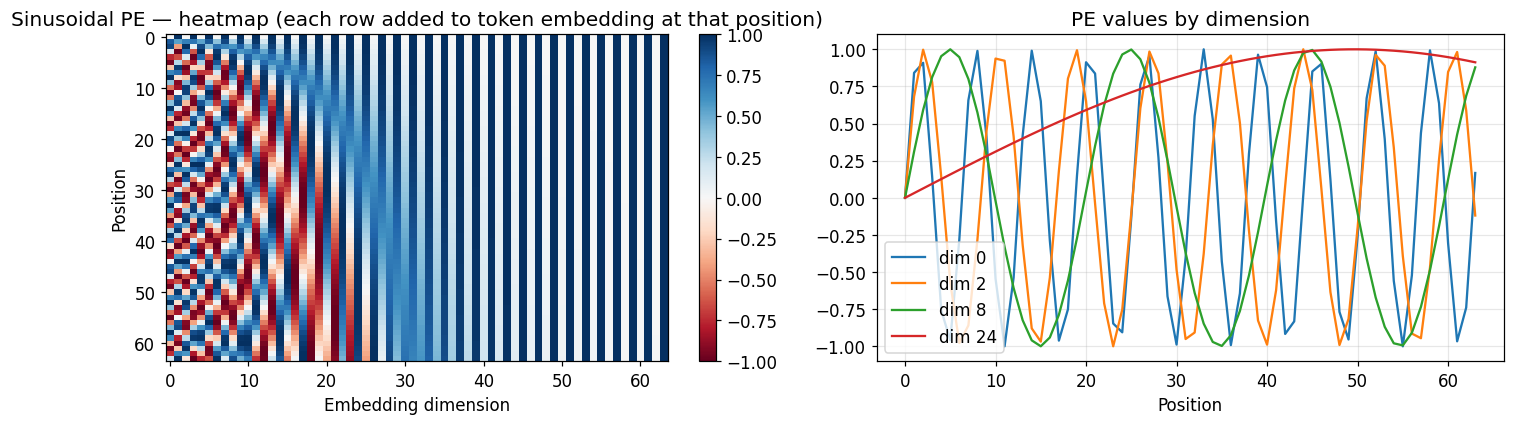

Low dimensions  → high-frequency waves  → fine-grained positional detail
High dimensions → low-frequency waves   → coarse positional context


In [ ]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed sinusoidal position signals added to token embeddings (Vaswani et al. 2017).

    Formula (for position `pos` and dimension-pair index `i`):
        PE[pos, 2i]   = sin(pos / 10000^(2i / d_model))
        PE[pos, 2i+1] = cos(pos / 10000^(2i / d_model))

    The encoding table is computed once at construction time and stored as a
    non-learnable buffer — it moves with .to(device) but is excluded from
    optimizer updates and gradient computation.

    Args:
        d_model : model (embedding) dimension
        max_len : maximum sequence length supported
        dropout : applied to the (embedding + PE) sum before the first block
    """
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)                             # (L, D)
        pos = torch.arange(0, max_len).unsqueeze(1).float()             # (L, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )                                                               # (D/2,)
        pe[:, 0::2] = torch.sin(pos * div)   # even dimensions
        pe[:, 1::2] = torch.cos(pos * div)   # odd  dimensions
        self.register_buffer("pe", pe.unsqueeze(0))                    # (1, L, D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model) — same tensor with position signal added
        """
        return self.dropout(x + self.pe[:, : x.size(1)])


class LearnedPositionalEncoding(nn.Module):
    """
    Trainable position embedding table (used by BERT, GPT-2).

    Each position index maps to a learnable d_model-dimensional vector,
    trained jointly with the rest of the model via gradient descent.

    Injection point: swap this for SinusoidalPositionalEncoding in GPT.__init__
    to switch between fixed and learned encodings without touching any other code.

    Args:
        d_model : model dimension
        max_len : maximum sequence length (= vocabulary of position indices)
        dropout : applied after adding position embedding
    """
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.emb     = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model)
        """
        T   = x.size(1)
        pos = torch.arange(T, device=x.device)
        return self.dropout(x + self.emb(pos))


# ── Visualise the sinusoidal encoding table ──────────────────────────────────
_pe_mod   = SinusoidalPositionalEncoding(d_model=64, max_len=64, dropout=0.0)
_pe_table = _pe_mod.pe.squeeze(0).numpy()   # (64, 64)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(_pe_table, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
axes[0].set_xlabel("Embedding dimension"); axes[0].set_ylabel("Position")
axes[0].set_title("Sinusoidal PE — heatmap (each row added to token embedding at that position)")
plt.colorbar(im, ax=axes[0])

for dim in [0, 2, 8, 24]:
    axes[1].plot(_pe_table[:, dim], label=f"dim {dim}")
axes[1].set_xlabel("Position"); axes[1].set_title("PE values by dimension")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Low dimensions  → high-frequency waves  → fine-grained positional detail")
print("High dimensions → low-frequency waves   → coarse positional context")

#### Interpretation: why multiple frequencies?

- **Low-index dims** (e.g. dim 0) flip sign almost every token — they encode
  **fine-grained position** and can distinguish token 5 from token 6.
- **High-index dims** (e.g. dim 32) change slowly over 50 positions — they encode
  **coarse, global position** and can distinguish the first half from the second.
- Together, all $d/2$ frequency pairs give every position a **unique fingerprint**
  across the full spectrum — like a binary counter where low bits flip fast and
  high bits flip slowly.

### 1.3 Scaled Dot-Product Attention

Before transformers, RNNs processed text one token at a time — each position had to wait for all previous positions to finish. Attention eliminates the queue: **every token reads from every other token simultaneously**, in one parallel matrix operation.

The mechanism gives each position three roles:

- **Query ($Q$):** a question — *"what information am I looking for?"*
- **Key ($K$):** an advertisement — *"what information do I carry?"*
- **Value ($V$):** the payload — *"what do I contribute when attended to?"*

Think of it like a soft database lookup: the query finds the most relevant keys, then retrieves a weighted blend of their values. The output for each token is a context-aware summary of the whole sequence.

**Input:** $X \in \mathbb{R}^{n \times d}$ — one row per token.

We walk through all six sub-operations on three tokens — `"the"`, `"cat"`, `"sat"` — with $d_k = 4$.

#### 1.3.1 Step 1: Linear projections

The same input $X$ is projected three times into different subspaces — one for asking questions, one for advertising content, one for carrying payloads:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V \qquad \in \mathbb{R}^{n \times d_k}$$

Each projection matrix is learned independently. $W_Q$ shapes what queries look like; $W_K$ shapes what keys look like; $W_V$ shapes what information gets extracted.

| Symbol | Shape | Role |
|--------|-------|------|
| $W_Q, W_K$ | $\mathbb{R}^{d \times d_k}$ | Project into the comparison space |
| $W_V$ | $\mathbb{R}^{d \times d_v}$ | Project into the information-extraction space |

*(For this walkthrough, the $W$ multiplications are skipped — Q, K, V are set directly.)*

In [ ]:
# ── Step 1 — Define Q, K, V ──────────────────────────────────────────────────
np.set_printoptions(precision=3, suppress=True)

tokens = ["the", "cat", "sat"]
d_k    = 4                     # head dimension

Q = np.array([[1,0,1,0],[0,1,0,1],[1,1,0,0]], dtype=float)    # (3, 4)
K = np.array([[1,0,1,0],[0,1,0,1],[0,0,1,1]], dtype=float)    # (3, 4)
V = np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12]], dtype=float)  # (3, 4)

print("── Step 1 complete: Q, K, V ──")
print(f"Q  {Q.shape}:\n{Q}")
print(f"\nK  {K.shape}:\n{K}")
print(f"\nV  {V.shape}:\n{V}")


── Step 1 complete: Q, K, V ──
Q  (3, 4):
[[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [1. 1. 0. 0.]]

K  (3, 4):
[[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [0. 0. 1. 1.]]

V  (3, 4):
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]


#### 1.3.2 Steps 2 + 3: Similarity scores and scaling

**How similar is query $i$ to key $j$?** Dot product:

$$S = QK^\top \in \mathbb{R}^{n \times n}, \qquad S_{ij} = \mathbf{q}_i \cdot \mathbf{k}_j$$

$S_{ij}$ is large when query $i$ and key $j$ point in similar directions — token $i$ finds token $j$ relevant.

**Why divide by $\sqrt{d_k}$?** Each dot product sums $d_k$ independent terms, so its variance grows with $d_k$. Without scaling, large models push softmax into its saturation plateau where gradients vanish and all tokens receive nearly uniform attention. Dividing by $\sqrt{d_k}$ restores variance $\approx 1$:

$$S_{\text{scaled}} = \frac{S}{\sqrt{d_k}}$$

In [ ]:
# ── Step 2+3 — Raw scores then scaling ───────────────────────────────────────
S        = Q @ K.T                  # (3, 3)  raw dot products
S_scaled = S / np.sqrt(d_k)        # (3, 3)  unit-variance scores

print("── Steps 2+3 complete: S and S_scaled ──")
print(f"\nS = Q @ Kᵀ  {S.shape}:")
print(S)
print(f"\nS_scaled = S / √{d_k}  (÷ {np.sqrt(d_k):.2f}):")
print(S_scaled)
print(f"\nVariance  before scaling: {S.var():.3f}")
print(f"Variance  after  scaling: {S_scaled.var():.3f}")

── Steps 2+3 complete: S and S_scaled ──

S = Q @ Kᵀ  (3, 3):
[[2. 0. 1.]
 [0. 2. 1.]
 [1. 1. 0.]]

S_scaled = S / √4  (÷ 2.00):
[[1.  0.  0.5]
 [0.  1.  0.5]
 [0.5 0.5 0. ]]

Variance  before scaling: 0.543
Variance  after  scaling: 0.136


#### 1.3.3 Step 4: Causal mask — blocking the future

For next-token prediction, position $i$ must **not** see any future position $j > i$ — if it could, the model would trivially read the answer and the training loss would be artificially low.

The fix is an additive mask applied before softmax:

$$M_{ij} = \begin{cases} 0 & j \leq i \quad \text{(past and present — allowed)} \\ -\infty & j > i \quad \text{(future — blocked)} \end{cases}$$

$e^{-\infty} = 0$ after softmax, so future tokens receive **exactly zero** attention weight — not just small weight. The upper triangle is completely zeroed out.

In [ ]:
# ── Step 4 — Apply causal mask ───────────────────────────────────────────────
mask     = np.triu(np.full((3, 3), -np.inf), k=1)   # upper-triangle only
S_masked = S_scaled + mask

print("── Step 4 complete: causal mask applied ──")
print(f"\nMask M  (upper-triangle = −∞):")
print(mask)
print(f"\nS_masked = S_scaled + M:")
print(S_masked)
print()
print("'the' (row 0) can attend to: itself only")
print("'cat' (row 1) can attend to: 'the', 'cat'")
print("'sat' (row 2) can attend to: 'the', 'cat', 'sat'")

── Step 4 complete: causal mask applied ──

Mask M  (upper-triangle = −∞):
[[  0. -inf -inf]
 [  0.   0. -inf]
 [  0.   0.   0.]]

S_masked = S_scaled + M:
[[ 1.  -inf -inf]
 [ 0.   1.  -inf]
 [ 0.5  0.5  0. ]]

'the' (row 0) can attend to: itself only
'cat' (row 1) can attend to: 'the', 'cat'
'sat' (row 2) can attend to: 'the', 'cat', 'sat'


#### 1.3.4 Step 5: Softmax → attention weights

Convert the masked scores to a **probability distribution** over positions for each query:

$$A = \text{softmax}(S_{\text{masked}}) \in \mathbb{R}^{n \times n}$$

Row $i$ of $A$ answers: "how much does token $i$ attend to each past position?" Every row sums to 1, all weights are non-negative, and the upper triangle is exactly 0.

$$A_{ij} \geq 0, \qquad \sum_j A_{ij} = 1$$

In [ ]:
# ── Step 5 — Softmax → attention weights ─────────────────────────────────────
def _softmax(x):
    e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))   # stable
    return e / e.sum(axis=1, keepdims=True)

A = _softmax(S_masked)

print("── Step 5 complete: attention weights A ──")
print()
for tok, row in zip(tokens, A):
    print(f"  {tok:>4}: {row}   sum = {row.sum():.3f}")
print()
print(f"Future positions blocked — A[0,1]={A[0,1]:.0f}  A[0,2]={A[0,2]:.0f}  A[1,2]={A[1,2]:.0f}")

── Step 5 complete: attention weights A ──

   the: [1. 0. 0.]   sum = 1.000
   cat: [0.269 0.731 0.   ]   sum = 1.000
   sat: [0.384 0.384 0.233]   sum = 1.000

Future positions blocked — A[0,1]=0  A[0,2]=0  A[1,2]=0


#### 1.3.5 Step 6: Weighted sum → context vectors

Each output is a **mixture of value vectors**, blended according to how much each position attended to each other:

$$O = AV \in \mathbb{R}^{n \times d_v}, \qquad O_i = \sum_{j \leq i} A_{ij}\, V_j$$

If token "cat" attends 80% to "the" and 20% to itself, its output is 80% of "the"'s value vector + 20% of its own. The result is a context-aware representation of each token, built from exactly the positions the model found relevant.

In [ ]:
# ── Step 6 — Weighted sum of values → output ─────────────────────────────────
O = A @ V    # (3, 4)

print("── Step 6 complete: output O = A @ V ──")
print()
for tok, row in zip(tokens, O):
    print(f"  {tok:>4}: {row}")
print()
print(f"'the' sees only itself  → O[0] == V[0]?  {np.allclose(O[0], V[0])}")
print(f"'cat' blends V[0]+V[1]  weights: {A[1,:2].round(3)}")
print(f"'sat' blends all three  weights: {A[2].round(3)}")

── Step 6 complete: output O = A @ V ──

   the: [1. 2. 3. 4.]
   cat: [3.924 4.924 5.924 6.924]
   sat: [4.396 5.396 6.396 7.396]

'the' sees only itself  → O[0] == V[0]?  True
'cat' blends V[0]+V[1]  weights: [0.269 0.731]
'sat' blends all three  weights: [0.384 0.384 0.233]


#### 1.3.6 Complete formula

$$\boxed{\text{Attention}(Q, K, V) =
  \text{softmax}\!\left(\frac{QK^\top + M}{\sqrt{d_k}}\right)V}$$

The six steps collapse into one expression — every sub-expression maps directly
to a step above.

> **One head, one relational pattern.** Section 1.4 stacks $h$ independent heads
> in parallel so the model can simultaneously track multiple relationship types.

---

**→ PyTorch implementation** — the class below is a direct translation:
batch dimensions added, dropout applied to $A$ as a regulariser, and the causal
mask pre-registered as a buffer in `MultiHeadAttention`.

In [ ]:
class ScaledDotProductAttention(nn.Module):
    """
    Core attention kernel: softmax( (Q K^T + M) / sqrt(d_k) ) V

    This module implements only the mathematical computation — it holds no
    projection weights. MultiHeadAttention wraps it and owns W_Q, W_K, W_V, W_O.

    Separating the kernel from the projections makes it straightforward to
    swap in Flash Attention or other efficient implementations later.

    Args:
        dropout : applied to the attention weight matrix A before multiplying V.
                  Acts as a regulariser during training (Srivastava et al. 2014).
    """
    def __init__(self, dropout: float = 0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        mask: Optional[torch.Tensor] = None,
        return_weights: bool = False,
    ):
        """
        Args:
            Q             : (..., n_q, d_k)
            K             : (..., n_k, d_k)
            V             : (..., n_k, d_v)
            mask          : (..., n_q, n_k) additive mask; use -inf to block positions
            return_weights: if True, also return A of shape (..., n_q, n_k)
        Returns:
            output  : (..., n_q, d_v)
            weights : (..., n_q, n_k)  — only when return_weights=True
        """
        d_k    = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # Step 2+3

        if mask is not None:
            scores = scores + mask    # Step 4: additive; -inf → 0 after softmax

        weights = F.softmax(scores, dim=-1)   # Step 5
        weights = self.dropout(weights)
        output  = torch.matmul(weights, V)    # Step 6

        if return_weights:
            return output, weights
        return output



### 1.4 Multi-Head Attention

One attention head is like one search query — it can track one relationship at a time: subject–verb agreement *or* pronoun coreference *or* local syntax. But language has many relationships active simultaneously.

**Multi-head attention runs $h$ independent attention functions in parallel**, each in a smaller $d_k = d/h$ subspace. Each head sees the same input but learns different projections, so it attends to different aspects of the sequence. The outputs are concatenated and mixed back:

$$\text{head}_i = \text{Attention}(XW_i^Q,\; XW_i^K,\; XW_i^V)$$

$$\text{MHA}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W^O$$

| Symbol | Shape | Description |
|--------|-------|-------------|
| $W_i^Q, W_i^K, W_i^V$ | $\mathbb{R}^{d \times d/h}$ | Per-head projections (each head learns independently) |
| $W^O$ | $\mathbb{R}^{d \times d}$ | Output projection — mixes all heads back to $d$ |

**Key fact:** Total parameter count is the same regardless of $h$ — $3d^2$ for Q/K/V, $d^2$ for output = **$4d^2$ total**. More heads subdivides the same budget into finer-grained specialisation.

Clark et al. (2019) verified head specialisation in BERT: specific heads reliably track direct objects, coreference, and sentence boundaries. The visualisation in section 3.6 lets you see this on our trained model.

> **Note:** Attention outputs can have arbitrary scale. Adding them into a deep residual stack without normalisation causes gradients to explode. Layer Normalisation is next.

**→ Implementation** — instead of three separate $W_Q$, $W_K$, $W_V$ matrices,
`MultiHeadAttention` uses one fused `nn.Linear(d, 3*d)` projection and splits
the output. This reduces three matrix multiplies to one — roughly 30 % faster
on modern hardware. The per-head views and the `ScaledDotProductAttention`
module from section 1.3 are reused directly.

In [ ]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention with optional causal masking (Vaswani et al. 2017).

    Uses a fused QKV projection (one Linear instead of three) for efficiency,
    then splits the output by head before computing attention in parallel.
    ScaledDotProductAttention is injected as the inner computation kernel.

    Dependency injection:
        attn_dropout : controls regularisation inside the attention kernel
        out_dropout  : controls regularisation on the output projection
        causal       : set True for GPT decoder blocks (registers causal mask buffer)
        bias         : set False for parameter efficiency (follows LLaMA convention)

    Args:
        d_model      : total model dimension d; must be divisible by n_head
        n_head       : number of attention heads h; head_dim = d / h
        attn_dropout : dropout rate applied to attention weights A
        out_dropout  : dropout rate applied after the output projection W_O
        bias         : include bias terms in projection layers
        causal       : if True, pre-allocate and register an upper-triangular -inf mask
        max_len      : pre-allocated causal mask size (must be >= block_size)
    """
    def __init__(
        self,
        d_model      : int,
        n_head       : int,
        attn_dropout : float = 0.0,
        out_dropout  : float = 0.0,
        bias         : bool  = False,
        causal       : bool  = False,
        max_len      : int   = 2048,
    ):
        super().__init__()
        assert d_model % n_head == 0, "d_model must be divisible by n_head"
        self.n_head   = n_head
        self.d_model  = d_model
        self.head_dim = d_model // n_head

        # Fused Q, K, V: one Linear(d, 3d) then split — same math, fewer kernel launches
        self.c_attn   = nn.Linear(d_model, 3 * d_model, bias=bias)
        self.c_proj   = nn.Linear(d_model, d_model,     bias=bias)
        self.out_drop = nn.Dropout(out_dropout)
        self.attn     = ScaledDotProductAttention(dropout=attn_dropout)

        if causal:
            # Upper-triangular -inf mask stored as a buffer (not a parameter)
            mask = torch.full((max_len, max_len), float("-inf"))
            mask = torch.triu(mask, diagonal=1)
            self.register_buffer("causal_mask", mask)
        else:
            self.causal_mask = None

    def forward(
        self,
        x                : torch.Tensor,
        key_padding_mask : Optional[torch.Tensor] = None,
        return_weights   : bool = False,
    ):
        """
        Args:
            x                : (B, T, d_model) — input sequence
            key_padding_mask : (B, T) bool — True marks padding positions to ignore
            return_weights   : if True, return attention weights for visualisation
        Returns:
            output  : (B, T, d_model)
            weights : (B, n_head, T, T) — only when return_weights=True
        """
        B, T, _ = x.shape
        H, D    = self.n_head, self.head_dim

        # Fused projection then split: (B, T, 3d) → three × (B, T, d)
        q, k, v = self.c_attn(x).split(self.d_model, dim=2)

        # Reshape to (B, H, T, head_dim) for batched multi-head attention
        q = q.view(B, T, H, D).transpose(1, 2)
        k = k.view(B, T, H, D).transpose(1, 2)
        v = v.view(B, T, H, D).transpose(1, 2)

        # Build composite mask (causal + optional key padding)
        mask = None
        if self.causal_mask is not None:
            mask = self.causal_mask[:T, :T].unsqueeze(0).unsqueeze(0)  # (1, 1, T, T)
        if key_padding_mask is not None:
            pad = key_padding_mask.float().masked_fill(
                key_padding_mask, float("-inf")
            ).view(B, 1, 1, T)
            mask = pad if mask is None else mask + pad

        out, weights = self.attn(q, k, v, mask=mask, return_weights=True)

        # Merge heads: (B, H, T, D) → (B, T, d_model)
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        out = self.out_drop(self.c_proj(out))

        if return_weights:
            return out, weights
        return out


# ── Functional test ───────────────────────────────────────────────────────────
torch.manual_seed(0)
_mha     = MultiHeadAttention(d_model=64, n_head=4, causal=True)
_x_mha   = torch.randn(2, 10, 64)
_o, _w   = _mha(_x_mha, return_weights=True)
print(f"MHA input  shape : {_x_mha.shape}")
print(f"MHA output shape : {_o.shape}   (B, T, d_model — shape preserved)")
print(f"Attn weights     : {_w.shape}   (B, n_head, T, T)")
assert _o.shape == _x_mha.shape


# ── Visualise heads ───────────────────────────────────────────────────────────
def plot_mha_weights(weights: torch.Tensor, tokens: List[str], title: str = ""):
    """Heatmap of each attention head for a single-batch example."""
    W   = weights[0].detach().cpu().numpy()   # (H, T, T)
    H   = W.shape[0]
    fig, axes = plt.subplots(1, H, figsize=(4 * H, 4))
    if H == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        sns.heatmap(W[i], xticklabels=tokens, yticklabels=tokens,
                    cmap="YlGnBu", ax=ax, cbar=True, vmin=0, annot=False)
        ax.set_title(f"Head {i + 1}", fontsize=10)
        ax.set_xlabel("Key"); ax.set_ylabel("Query")
    if title:
        plt.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()


MHA input  shape : torch.Size([2, 10, 64])
MHA output shape : torch.Size([2, 10, 64])   (B, T, d_model — shape preserved)
Attn weights     : torch.Size([2, 4, 10, 10])   (B, n_head, T, T)


### 1.5 Layer Normalisation (Ba et al., 2016)

As a model trains, the distribution of activations at each layer shifts — downstream layers must constantly readapt to a moving target. This **internal covariate shift** slows training and destabilises deep networks.

**Why not BatchNorm?** BatchNorm normalises across the *batch* — it needs statistics from many samples simultaneously. For language models: sequences have variable length, batch sizes are small (often 1–4 for large models), and at inference the batch is size 1. BatchNorm statistics become unreliable. LayerNorm normalises each token's own feature vector independently — no cross-sample dependency.


**Pre-LN vs Post-LN:**

| | Update rule | Behaviour |
|--|------------|----------|
| Post-LN (2017 original) | $\text{LN}(x + F(x))$ | Unstable in deep networks without careful warmup |
| **Pre-LN (used here)** | $x + F(\text{LN}(x))$ | Input to $F$ is always normalised — stable at 100+ layers |

GPT-2, GPT-3, and LLaMA all use Pre-LN. Every block in this notebook does too.

In [ ]:
class LayerNorm(nn.Module):
    """
    Layer normalisation over the last (embedding) dimension (Ba et al. 2016).

    Implements:
        LN(x) = gamma * (x - mu) / sqrt(sigma^2 + eps) + beta

    where mu and sigma^2 are computed per-token over the d_model dimension,
    and gamma, beta are learnable per-dimension scale and shift parameters.

    Writing this explicitly (rather than using nn.LayerNorm directly) makes
    the normalisation statistics and learnable parameters fully visible,
    which is valuable when ablating or replacing this component.

    Args:
        d_model : embedding dimension to normalise over
        eps     : numerical stability constant (avoids division by zero)
    """
    def __init__(self, d_model: int, eps: float = 1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))    # learnable scale
        self.beta  = nn.Parameter(torch.zeros(d_model))   # learnable shift
        self.eps   = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (..., d_model)
        Returns:
            (..., d_model) — same shape, normalised per last dimension
        """
        mu  = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.gamma * (x - mu) / torch.sqrt(var + self.eps) + self.beta


# ── Verify: output should have ~zero mean, ~unit std per token ────────────────
# torch.manual_seed(0)
# _x_ln = torch.randn(2, 6, 32) * 5 + 3    # deliberately off-centred
# _ln   = LayerNorm(32)
# _out_ln = _ln(_x_ln)

# print(f"Input  — mean: {_x_ln[0, 0].mean().item():.3f}   std: {_x_ln[0, 0].std().item():.3f}")
# print(f"Output — mean: {_out_ln[0, 0].mean().item():.5f}  std: {_out_ln[0, 0].std().item():.4f}")
# print(f"(Output mean ≈ 0 and std ≈ 1 before gamma/beta rescaling)")
# assert _out_ln.shape == _x_ln.shape


### 1.6 Position-wise Feed-Forward Network (FFN)

Attention is a **linear** weighted average of value vectors — a model with only attention layers can only express linear transformations, regardless of depth. The FFN provides the non-linearity that makes transformers universally expressive.

**Division of labour:** attention *routes* information between positions (which tokens communicate with which); the FFN *processes* that information within each token's representation (what to do with what was gathered). Geva et al. (2021) showed FFN layers behave like key-value memories — specific neurons activate for "Eiffel Tower" and boost "Paris" in the output distribution.

Applied **independently and identically to every token position**:

$$\text{FFN}(x) = W_2\,\sigma(W_1 x + b_1) + b_2$$

| Symbol | Shape | Description |
|--------|-------|-------------|
| $W_1$ | $\mathbb{R}^{d \times 4d}$ | Expand: project to a $4\times$ wider space |
| $W_2$ | $\mathbb{R}^{4d \times d}$ | Contract: project back to model dimension |
| $\sigma$ | — | Non-linear activation (GELU here) |

The 4× expansion factor is empirical — a wider intermediate space provides more neurons to detect fine-grained patterns. Parameter count per FFN: $8d^2$.

**Activation choices:**

| Activation | Formula | Used in |
|-----------|---------|--------|
| ReLU | $\max(0, x)$ | Original Transformer (2017) |
| GELU | $x\,\Phi(x)$ | GPT-2, BERT |
| SwiGLU | $\text{Swish}(xW_1) \odot (xW_3)$ | LLaMA, PaLM |

> **Note:** FFNs process each token independently, but naively stacking many such layers causes gradients to vanish at the bottom. Residual connections fix this.

**→ Implementation** — `PositionwiseFFN` is a two-linear-layer MLP.
The `activation` argument is the dependency-injection point for $\sigma$:
pass `nn.GELU()` for GPT-2 style, or `nn.ReLU()` to replicate the original
2017 Transformer — no changes inside the class required.

In [ ]:
class PositionwiseFFN(nn.Module):
    """
    Two-layer MLP applied independently to each sequence position.

    FFN(x) = W_2 * activation(W_1 * x)

    Default expansion: d_model → 4*d_model → d_model (Vaswani et al. 2017).

    Dependency injection:
        activation : any nn.Module callable applied element-wise between layers.
                     Defaults to nn.GELU() if None.
                     Pass nn.ReLU() to replicate the original Transformer,
                     nn.SiLU() for a Swish-style FFN, etc.
        d_ff       : inner (expanded) dimension. Defaults to 4*d_model if None.

    Args:
        d_model    : input and output dimension
        d_ff       : FFN inner dimension (None → 4 * d_model)
        activation : element-wise activation module (None → nn.GELU())
        dropout    : applied after activation and after the output projection
    """
    def __init__(
        self,
        d_model    : int,
        d_ff       : Optional[int]   = None,
        activation : Optional[nn.Module] = None,
        dropout    : float = 0.1,
    ):
        super().__init__()
        d_ff       = d_ff       or 4 * d_model
        activation = activation or nn.GELU()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff, bias=False),
            activation,
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model, bias=False),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, T, d_model) → (B, T, d_model) — shape preserved"""
        return self.net(x)


# ── Verify shape and compare activations ─────────────────────────────────────
_x_ffn = torch.randn(2, 6, 32)
for act_name, act in [
    ("GELU (default)", None),
    ("ReLU",           nn.ReLU()),
    ("SiLU",           nn.SiLU()),
]:
    _ffn = PositionwiseFFN(d_model=32, activation=act)
    _o   = _ffn(_x_ffn)
    n_p  = sum(p.numel() for p in _ffn.parameters())
    print(f"{act_name:<22} output: {_o.shape}   params: {n_p:,}")

GELU (default)         output: torch.Size([2, 6, 32])   params: 8,192
ReLU                   output: torch.Size([2, 6, 32])   params: 8,192
SiLU                   output: torch.Size([2, 6, 32])   params: 8,192


### 1.7 Residual Connections & Gradient Flow

Stacking many layers compounds a fundamental problem: gradients must be multiplied through every layer's Jacobian on the backward pass. In a 12-layer network, a gradient of 0.9 per layer survives as $0.9^{12} \approx 0.28$ — in a 96-layer network, it vanishes to essentially zero. This is the **vanishing gradient problem**.

**Residual connections** solve it with a single addition — each layer adds its transformation to the input rather than replacing it:

$$x_{l+1} = x_l + F_l(x_l)$$

The identity path $x_l$ gives gradients a **direct highway** back through the full network, bypassing every layer's Jacobian. Training at 96+ layers is only possible because of this.

---

### 1.8 Full GPT Block with Prelayer Normalization

Each block runs two sub-layers — attention and FFN — each with a preceding LayerNorm and a residual connection:

$$x' = x + \text{MHA}(\text{LN}(x)) \qquad \text{(attention + residual)}$$
$$x'' = x' + \text{FFN}(\text{LN}(x')) \qquad \text{(FFN + residual)}$$

After $L$ such blocks, a final LayerNorm and linear projection produces vocabulary logits:

$$\text{logits} = \text{LN}(X^{(L)})\, W_{\text{unembed}} \in \mathbb{R}^{n \times V}$$


**→ Implementation — assembling the full GPT**

The two equations from section 1.7 map directly to code:

| Equation | Code location |
|----------|--------------|
| $x' = x + \text{MHA}(\text{LN}(x))$ | `GPTBlock.forward()` — first residual addition |
| $x'' = x' + \text{FFN}(\text{LN}(x'))$ | `GPTBlock.forward()` — second residual addition |
| $\text{logits} = \text{LN}(X^{(L)})W_{\text{unembed}}$ | `GPT.forward()` — final LayerNorm + linear |

`GPT` stacks $L$ `GPTBlock`s, applies a final LayerNorm, and projects to logits
via the **weight-tied** LM head (`lm_head.weight = token_emb.weight.T`).

In [ ]:
@dataclass
class GPTConfig:
    """
    Hyperparameters for a GPT-style decoder-only transformer.

    All block-level module choices (norm class, activation) default to standard
    values but can be overridden at GPT construction time via dependency injection.

    Attributes:
        vocab_size : V — number of distinct token types
        block_size : n — maximum context window (sequence length)
        n_layer    : L — number of stacked transformer blocks
        n_head     : h — number of attention heads per block (must divide n_embd)
        n_embd     : d — model (embedding) dimension
        d_ff       : FFN inner dimension; None defaults to 4 * n_embd inside FFN
        dropout    : dropout rate used in PE, attention weights, FFN, and residuals
    """
    vocab_size : int            = 8_000
    block_size : int            = 256
    n_layer    : int            = 6
    n_head     : int            = 8
    n_embd     : int            = 256
    d_ff       : Optional[int]  = None
    dropout    : float          = 0.10

In [ ]:
class GPTBlock(nn.Module):
    """
    One Pre-LN GPT decoder block:

        x  ──► LayerNorm ──► CausalMHA ──► + residual ──► x'
        x' ──► LayerNorm ──► FFN       ──► + residual ──► output

    Dependency injection:
        norm_class : normalisation class; called as norm_class(d_model).
                     Default nn.LayerNorm. Swap for custom LayerNorm (above)
                     or RMSNorm to replicate LLaMA behaviour.
        activation : activation module injected into PositionwiseFFN.
                     Default None (resolved to nn.GELU() inside FFN).
                     Pass nn.ReLU() for original Transformer behaviour.

    Args:
        config     : GPTConfig instance carrying all hyperparameters
        norm_class : normalisation class (not instance — block creates two)
        activation : activation instance for FFN (None → GELU)
    """
    def __init__(
        self,
        config     : GPTConfig,
        norm_class : Type[nn.Module]      = nn.LayerNorm,
        activation : Optional[nn.Module] = None,
    ):
        super().__init__()
        self.norm1 = norm_class(config.n_embd)
        self.attn  = MultiHeadAttention(
            d_model      = config.n_embd,
            n_head       = config.n_head,
            attn_dropout = config.dropout,
            out_dropout  = config.dropout,
            bias         = False,
            causal       = True,
            max_len      = config.block_size,
        )
        self.norm2 = norm_class(config.n_embd)
        self.ffn   = PositionwiseFFN(
            d_model    = config.n_embd,
            d_ff       = config.d_ff,
            activation = activation,
            dropout    = config.dropout,
        )

    def forward(
        self,
        x              : torch.Tensor,
        return_weights : bool = False,
    ):
        """
        Args:
            x              : (B, T, d_model)
            return_weights : if True, also return the attention weight tensor
        Returns:
            output  : (B, T, d_model)
            weights : (B, n_head, T, T) — only when return_weights=True
        """
        # Sub-layer 1: Pre-LN → MHA → residual
        if return_weights:
            attn_out, weights = self.attn(self.norm1(x), return_weights=True)
        else:
            attn_out = self.attn(self.norm1(x))
        x = x + attn_out

        # Sub-layer 2: Pre-LN → FFN → residual
        x = x + self.ffn(self.norm2(x))

        if return_weights:
            return x, weights
        return x

In [ ]:
class GPT(nn.Module):
    """
    Decoder-only GPT (Radford et al. 2018 / Brown et al. 2020).

    Architecture:
        Token Embedding  (V × d)
        Positional Encoder  (injected)
        n_layer × block_class  (injected)
        Final LayerNorm
        LM Head  (d × V, weight-tied to token embedding)

    Dependency injection:
        pos_encoder : positional encoder instance.
                      Inject SinusoidalPositionalEncoding for fixed sinusoidal
                      encodings, or LearnedPositionalEncoding for GPT-2 style.
                      Any nn.Module with signature (B, T, d) → (B, T, d) works.

        block_class : transformer block class.
                      Must accept (config, norm_class, activation) as its first
                      three constructor arguments. Swap in a custom block
                      (e.g., one with sliding-window attention) to experiment
                      without modifying GPT internals.

        norm_class  : normalisation class propagated to every block AND the final
                      LayerNorm. Swap nn.LayerNorm for custom LayerNorm or RMSNorm.

        activation  : activation module propagated to every block's FFN.
                      None → GELU inside PositionwiseFFN.

    Args:
        config      : GPTConfig
        pos_encoder : positional encoder instance (already constructed)
        block_class : transformer block class (not instance)
        norm_class  : normalisation class (not instance)
        activation  : activation module for FFN (None → GELU)
    """
    def __init__(
        self,
        config      : GPTConfig,
        pos_encoder : nn.Module,
        block_class : Type[nn.Module]     = GPTBlock,
        norm_class  : Type[nn.Module]     = nn.LayerNorm,
        activation  : Optional[nn.Module] = None,
    ):
        super().__init__()
        self.config = config

        self.tok_emb    = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_enc    = pos_encoder
        self.blocks     = nn.ModuleList([
            block_class(config, norm_class=norm_class, activation=activation)
            for _ in range(config.n_layer)
        ])
        self.final_norm = norm_class(config.n_embd)
        self.lm_head    = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying: LM head reuses the token embedding matrix transposed.
        # Saves V*d parameters; empirically improves perplexity (Press & Wolf 2017).
        self.lm_head.weight = self.tok_emb.weight

        self._init_weights()

    def _init_weights(self):
        # Pedagogical init: because the LM head is tied to tok_emb before this
        # loop runs, the same shared tensor is visited through both module handles.
        # That is harmless here because both branches use the same N(0, 0.02) init.
        # We keep this simple scheme instead of reproducing GPT-2's scaled c_proj init.
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(
        self,
        idx     : torch.Tensor,
        targets : Optional[torch.Tensor] = None,
    ):
        """
        Args:
            idx     : (B, T) integer token IDs; T must be <= block_size
            targets : (B, T) next-token target IDs; computes CE loss if provided
        Returns:
            logits : (B, T, V) — unnormalised next-token scores
            loss   : scalar cross-entropy loss, or None
        """
        B, T = idx.shape
        assert T <= self.config.block_size, (
            f"Input length {T} exceeds block_size {self.config.block_size}"
        )
        x = self.tok_emb(idx)   # (B, T, d)
        x = self.pos_enc(x)     # add positional signal

        for block in self.blocks:
            x = block(x)

        x      = self.final_norm(x)
        logits = self.lm_head(x)   # (B, T, V)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )
        return logits, loss

    def n_params(self) -> int:
        """Total parameter count; PyTorch already de-duplicates tied weights."""
        return sum(p.numel() for p in self.parameters())

    def get_all_attn_weights(self, idx: torch.Tensor) -> List[torch.Tensor]:
        """
        Forward pass collecting attention weights from every block.

        Collect attention weights from all layers for analysis and visualisation.

        Returns:
            List of n_layer tensors, each of shape (B, n_head, T, T).
        """
        x = self.pos_enc(self.tok_emb(idx))
        weights = []
        for block in self.blocks:
            x, w = block(x, return_weights=True)
            weights.append(w)
        return weights


In [ ]:
# ── Instantiate and verify parameter count ────────────────────────────────────
cfg = GPTConfig(
    vocab_size = 8_000,
    block_size = 256,
    n_layer    = 6,
    n_head     = 8,
    n_embd     = 256,
    dropout    = 0.10,
)

# Inject a learned positional encoder (GPT-2 style)
pos_enc = LearnedPositionalEncoding(
    d_model = cfg.n_embd,
    max_len = cfg.block_size,
    dropout = cfg.dropout,
)

model = GPT(
    config      = cfg,
    pos_encoder = pos_enc,
    block_class = GPTBlock,
    norm_class  = nn.LayerNorm,
    activation  = None,           # GELU (resolved inside PositionwiseFFN)
).to(device)

n_p         = model.n_params()
core_theory = cfg.vocab_size * cfg.n_embd + 12 * cfg.n_layer * cfg.n_embd**2
ln_params   = sum(
    p.numel() for name, p in model.named_parameters()
    if 'norm' in name
)
learned_pe_params = pos_enc.emb.weight.numel()
extras_expected   = learned_pe_params + ln_params

print(f"Actual parameters         : {n_p:,}")
print(f"Core formula Vd + 12Ld²  : {core_theory:,}")
print(f"Difference               : {n_p - core_theory:,}")
print(f"Expected extras          : {extras_expected:,}  (learned PE + LayerNorm)")

# Quick forward pass sanity check
_idx = torch.randint(0, cfg.vocab_size, (2, 16), device=device)
_tgt = torch.randint(0, cfg.vocab_size, (2, 16), device=device)
_logits, _loss = model(_idx, _tgt)
print(f"\nForward pass — logits: {_logits.shape}   loss: {_loss.item():.4f}")

# Swap to sinusoidal PE — no other code changes needed
pos_enc_sin = SinusoidalPositionalEncoding(
    d_model = cfg.n_embd,
    max_len = cfg.block_size,
    dropout = cfg.dropout,
)
model_sin = GPT(cfg, pos_encoder=pos_enc_sin).to(device)
sin_gap   = model_sin.n_params() - core_theory
print(f"\nModel with sinusoidal PE — params: {model_sin.n_params():,}")
print(f"Gap from core formula     : {sin_gap:,}  (LayerNorm only)")


Actual parameters         : 6,838,784
Core formula Vd + 12Ld²  : 6,766,592
Difference               : 72,192
Expected extras          : 72,192  (learned PE + LayerNorm)

Forward pass — logits: torch.Size([2, 16, 8000])   loss: 9.0447

Model with sinusoidal PE — params: 6,773,248
Gap from core formula     : 6,656  (LayerNorm only)


<a id="mod2"></a>

---
## Module 2: Tokenization & BPE
*BPE algorithm · Fertility · Vocabulary coverage*

Before a language model can learn anything, text has to be converted into tokens. This module introduces byte-pair encoding as the practical compromise between word-level and character-level tokenization, then shows how tokenization choices affect sequence length, vocabulary coverage, and ultimately compute cost. The emphasis is not just on how BPE works, but on why tokenizer design matters downstream.

### 2.1 Tokenization: Byte-Pair Encoding

Neural networks need numbers, not text. The question is what unit to tokenize at.

- **Word-level:** "running" and "runs" are completely different tokens — the vocabulary explodes, and unseen words get no representation.
- **Character-level:** every sequence becomes very long, and the model must learn to spell before it can learn meaning.
- **BPE (Byte-Pair Encoding)** is the middle ground. Start from individual bytes (256 initial tokens — zero out-of-vocabulary by construction for any Unicode input), then repeatedly merge the most frequent adjacent pair until the target vocabulary size is reached. The result: common words become single tokens; rare words split into recognisable sub-word pieces.

**Key metric — Fertility:**

Fertility $\phi$ measures how many tokens a tokenizer produces per source word:

$$\phi = \frac{\text{total tokens produced}}{\text{total words in input}}$$

Since attention cost scales as $O(n^2)$ in sequence length, a domain mismatch can be expensive: if an English-trained tokenizer produces twice as many tokens on Chinese text ($\phi_B = 2\phi_A$), that quadruples the attention compute cost on that domain.

> **Connection forward:** With a tokenizer ready, the next module defines the training objective and optimization loop.

In [ ]:
from datasets import load_dataset

print("Downloading TinyStories (10K samples)...")
raw   = load_dataset("roneneldan/TinyStories", split="train[:10000]", trust_remote_code=True)
texts = raw["text"]

print(f"Stories  : {len(texts):,}")
print(f"Sample   :\n{texts[0][:300]}")
print(f"\nAvg length: {sum(len(t) for t in texts) / len(texts):.0f} chars/story")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

...

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Stories  : 10,000
Sample   :
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and 

Avg length: 867 chars/story


In [ ]:
from tokenizers import ByteLevelBPETokenizer

VOCAB_SIZE  = 8_000
CORPUS_PATH = "tinystories_corpus.txt"
TOK_DIR     = "bpe_tokenizer"

# Write corpus to disk (ByteLevelBPETokenizer trains from files)
print(f"Writing corpus ({len(texts):,} stories)...")
with open(CORPUS_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(texts))
print(f"Corpus size: {os.path.getsize(CORPUS_PATH) / 1e6:.1f} MB")

# Train the tokenizer
print(f"\nTraining Byte-Level BPE tokenizer (vocab_size={VOCAB_SIZE})...")
t0 = time.time()
tokenizer = ByteLevelBPETokenizer()
tokenizer.train(
    files         = [CORPUS_PATH],
    vocab_size    = VOCAB_SIZE,
    min_frequency = 2,
    special_tokens= ["<pad>", "<eos>", "<unk>"],
)
os.makedirs(TOK_DIR, exist_ok=True)
tokenizer.save_model(TOK_DIR)
print(f"Done in {time.time() - t0:.1f}s — final vocab size: {tokenizer.get_vocab_size()}")

PAD_ID = tokenizer.token_to_id("<pad>")
EOS_ID = tokenizer.token_to_id("<eos>")
print(f"<pad> id = {PAD_ID}   <eos> id = {EOS_ID}")


Writing corpus (10,000 stories)...
Corpus size: 8.7 MB

Training Byte-Level BPE tokenizer (vocab_size=8000)...
Done in 5.1s — final vocab size: 8000
<pad> id = 0   <eos> id = 1


In [ ]:
# ── Fertility analysis on our trained tokenizer ───────────────────────────────
sample = "Once upon a time, there was a little dragon who was afraid of fire."
enc    = tokenizer.encode(sample)

print(f"Text     : {sample}")
print(f"Tokens   : {enc.tokens}")
print(f"IDs      : {enc.ids}")
print(f"\nWords    : {len(sample.split())}")
print(f"Tokens   : {len(enc.tokens)}")
print(f"Fertility: {len(enc.tokens) / len(sample.split()):.2f} tokens/word")

Text     : Once upon a time, there was a little dragon who was afraid of fire.
Tokens   : ['Once', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġthere', 'Ġwas', 'Ġa', 'Ġlittle', 'Ġdragon', 'Ġwho', 'Ġwas', 'Ġafraid', 'Ġof', 'Ġfire', '.']
IDs      : [424, 439, 261, 392, 14, 395, 282, 261, 390, 1757, 596, 282, 2139, 348, 1207, 16]

Words    : 14
Tokens   : 16
Fertility: 1.14 tokens/word


<a id="mod3"></a>

---
## Module 3: Pretraining
*NTP objective · Cross-entropy · AdamW · Cosine schedule*

This module turns the architecture and tokenizer into a trainable language model. We introduce next-token prediction, connect it to cross-entropy and perplexity, and then use a lightweight optimizer-and-schedule setup to train a small GPT on TinyStories. The main goal is to see how pretraining works end to end, not to dwell on optimizer theory.

### 3.1 Next-Token Prediction Objective

How do you train a model to understand language without any human labels?
The key insight behind every modern LLM: **text is its own supervision**.
The next word in any sentence is the label for everything that preceded it.
This self-supervised objective requires zero human annotation, scales to the
entire internet, and emerges from a single probabilistic principle.

Given a sequence $\mathbf{x} = (x_1, \ldots, x_T)$, the chain rule of probability
factorises the joint distribution exactly:

$$\log P(\mathbf{x};\theta) = \sum_{t=1}^{T} \log P(x_t \mid x_1, \ldots, x_{t-1};\theta)$$

| Symbol | Description |
|--------|-------------|
| $\theta$ | model parameters |
| $x_t$ | token at position $t$ |
| $T$ | sequence length |

This is **self-supervised**: the labels are the input itself, shifted by one position.
For a window $[x_1, \ldots, x_{T+1}]$:
- Input to model: $[x_1, \ldots, x_T]$
- Targets: $[x_2, \ldots, x_{T+1}]$

A single forward pass produces $T$ predictions and $T$ gradient signals simultaneously —
an extremely efficient use of each training example.

> **Connection forward:** Maximising log-likelihood is equivalent to minimising a
> loss function. Cross-entropy provides the differentiable form of this objective.

### 3.2 Cross-Entropy Loss

At each position, the model outputs a score for every token in the vocabulary. We convert those scores to probabilities via softmax, then ask: **how much probability did the model assign to the actual correct next token?**

- Model assigns 95% to the right word → loss is tiny (model is confident and correct)
- Model assigns 95% to the wrong word → loss is huge (model is confident and wrong)
- Model assigns 1/V uniform probability → loss = $\log V$ (model is completely lost)

This is captured by the **negative log-probability**:

$$ L_t = -\log P(x_t \mid x_{<t};\theta)$$

Averaged over a full sequence of length $T$:

$$ L = -\frac{1}{T}\sum_{t=1}^{T} \log P(x_t \mid x_{<t};\theta)$$

| Symbol | Description |
|--------|-------------|
| $v^*$ | Ground-truth next token at position $t$ |
| $z_{v^*}$ | Logit (raw score) for the correct token |
| $V$ | Vocabulary size |

> **Connection forward:** "Loss = 3.1" is hard to interpret. Perplexity converts this into an intuitive quantity — an effective vocabulary size.

### 3.3 Perplexity

Cross-entropy loss is the natural optimisation target, but "a loss of 3.1" is hard to communicate or compare across models. Perplexity reframes the same quantity as an **effective branching factor** — the number of equally likely next tokens the model perceives at each step.

$$\text{PPL} = e^{\mathcal{L}} = \exp\!\left(-\frac{1}{T}\sum_{t=1}^{T}\log P(x_t \mid x_{<t})\right)$$

**How to read it:** PPL = 10 means the model behaves as if it is choosing uniformly at random from 10 plausible candidates at every step — it has effectively narrowed the 50,000 vocabulary options down to 10.

| Model | Benchmark | PPL |
|-------|-----------|-----|
| Uniform over $V = 50{\text{K}}$ vocab | — | 50,000 |
| 5-gram LM | WikiText-103 | ~80 |
| GPT-2 (124M) | WikiText-103 | ~37 |
| LLaMA-3 (8B) | WikiText-2 | ~6.1 |

> **Connection forward:** With loss and metric defined, we need an optimizer to update weights efficiently. The scale of LLM training makes the choice of optimizer and learning-rate schedule critical.

### 3.4 AdamW Optimizer

We use **AdamW** because it is the standard optimizer for transformer pretraining.
It adapts the step size per parameter using running estimates of the gradient and
squared gradient, and it applies **decoupled weight decay** for regularisation.

For this notebook, the key point is simple: AdamW makes training stable enough
that we can focus on the language-model objective and the model's behaviour,
not on optimizer engineering details.

### 3.5 Learning-Rate Schedule: Warmup + Cosine Decay

We pair AdamW with a simple **warmup + cosine decay** schedule.
Warmup keeps the first updates small while the optimizer stabilises; cosine decay
then gradually reduces the learning rate so training becomes smoother later on.

In this notebook, treat the schedule as a practical training tool rather than a
main concept: it helps the tiny GPT train more reliably, but it is not the focus.

In [ ]:
from typing import Callable

class TinyStoriesDataset(Dataset):
    """
    Sequence-packing dataset for next-token-prediction pretraining.

    Concatenates all stories (separated by <eos>) into a single token stream,
    then slices it into non-overlapping windows of length block_size + 1.
    For each window:
        x = tokens[0 : block_size]       (input)
        y = tokens[1 : block_size + 1]   (next-token targets)

    This avoids all padding waste — every token in every batch contributes to
    the cross-entropy loss.

    Dependency injection:
        tokenizer : any object with .encode(text).ids and .token_to_id(special)
                    This matches the HuggingFace tokenizers interface, but the
                    class is not coupled to any specific tokenizer implementation.

    Args:
        texts      : list of raw text strings
        tokenizer  : tokenizer instance
        block_size : context window length (= model.config.block_size)
        max_tokens : cap on total tokens to tokenise (for faster iteration)
    """
    def __init__(
        self,
        texts      : List[str],
        tokenizer,
        block_size : int,
        max_tokens : int = 600_000,
    ):
        self.block_size = block_size
        eos_id = tokenizer.token_to_id("<eos>")

        print(f"Tokenising {len(texts):,} stories...")
        t0      = time.time()
        all_ids : List[int] = []
        for text in texts:
            all_ids.extend(tokenizer.encode(text).ids)
            all_ids.append(eos_id)
            if len(all_ids) >= max_tokens:
                break

        n    = block_size + 1
        trim = (len(all_ids) // n) * n
        self.data = torch.tensor(all_ids[:trim], dtype=torch.long)
        print(
            f"  {len(self.data):,} tokens → {len(self):,} sequences  "
            f"[{time.time() - t0:.1f}s]"
        )

    def __len__(self) -> int:
        return len(self.data) // (self.block_size + 1)

    def __getitem__(self, idx: int):
        chunk = self.data[
            idx * (self.block_size + 1) : (idx + 1) * (self.block_size + 1)
        ]
        return chunk[:-1], chunk[1:]


dataset = TinyStoriesDataset(texts, tokenizer, block_size=cfg.block_size)

Tokenising 10,000 stories...
  600,095 tokens → 2,335 sequences  [1.4s]


In [ ]:
def train(
    model,
    dataset    : Dataset,
    optimizer  : torch.optim.Optimizer,
    scheduler  : torch.optim.lr_scheduler._LRScheduler,
    max_steps  : int  = 2_000,
    batch_size : int  = 32,
    eval_every : int  = 100,
    gen_every  : int  = 500,
    gen_prompt : str  = "Once upon a time",
):
    """
    Pretraining loop with injected optimizer and scheduler.

    Dependency injection:
        optimizer : any torch.optim.Optimizer wrapping model.parameters().
                    Injecting it here (rather than creating it inside) allows
                    callers to configure weight decay, betas, and lr externally,
                    and makes the function testable with a mock optimizer.
        scheduler : any _LRScheduler; called once per step after optimizer.step().
                    Inject torch.optim.lr_scheduler.LambdaLR with a cosine-warmup
                    lambda, or ConstantLR for ablation studies.

    Args:
        model      : GPT instance (must have .forward(x, y) and .config)
        dataset    : TinyStoriesDataset (or any Dataset yielding (x, y) pairs)
        optimizer  : pre-built optimizer
        scheduler  : pre-built LR scheduler
        max_steps  : total number of gradient updates
        batch_size : sequences per batch
        eval_every : log loss every this many steps
        gen_every  : generate a text sample every this many steps
        gen_prompt : prompt string for intermediate generation samples
    Returns:
        history : dict with keys "step", "loss", "ppl"
    """
    loader    = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, num_workers=0,
        pin_memory=(device.type == "cuda"),
    )
    history   = {"step": [], "loss": [], "ppl": []}
    data_iter = iter(loader)
    t0        = time.time()

    model.train()
    print(f"Training {max_steps} steps | batch={batch_size}")
    print("-" * 60)

    for step in range(1, max_steps + 1):
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            x, y     = next(data_iter)

        x, y        = x.to(device), y.to(device)
        _, loss     = model(x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % eval_every == 0 or step == 1:
            ppl    = math.exp(min(loss.item(), 20))
            cur_lr = optimizer.param_groups[0]["lr"]
            history["step"].append(step)
            history["loss"].append(loss.item())
            history["ppl"].append(ppl)
            print(
                f"step {step:5d}/{max_steps} | loss={loss.item():.4f} | "
                f"ppl={ppl:6.1f} | lr={cur_lr:.2e} | {time.time()-t0:.0f}s"
            )

        if step % gen_every == 0:
            model.eval()
            with torch.no_grad():
                sample = _quick_generate(model, tokenizer, gen_prompt, max_new=60)
            print(f"\n  Sample @ step {step}:\n  {sample[:160]}\n")
            model.train()

    print(f"\nDone in {time.time() - t0:.0f}s")
    return history


@torch.no_grad()
def _quick_generate(model, tok, prompt: str, max_new: int = 1000,
                    temperature: float = 0.85, top_p: float = 0.9) -> str:
    """Minimal greedy/nucleus generation used only for training progress logging."""
    model.eval()
    eos_id = tok.token_to_id("<eos>")
    ids    = torch.tensor([tok.encode(prompt).ids], dtype=torch.long, device=device)
    for _ in range(max_new):
        ids_cond = ids[:, -model.config.block_size :]
        logits, _= model(ids_cond)
        logits   = logits[:, -1, :] / temperature
        sorted_l, sorted_i = torch.sort(logits, descending=True)
        cum_p    = torch.cumsum(F.softmax(sorted_l, dim=-1), dim=-1)
        remove   = cum_p - F.softmax(sorted_l, dim=-1) > top_p
        sorted_l[remove] = float("-inf")
        logits   = torch.zeros_like(logits).scatter(1, sorted_i, sorted_l)
        next_id  = torch.multinomial(F.softmax(logits, dim=-1), 1)
        ids      = torch.cat([ids, next_id], dim=1)
        if next_id.item() == eos_id:
            break
    return tok.decode(ids[0].tolist())


> A model that assigns *uniform* probability across
> all $V$ vocabulary tokens has loss $\mathcal{L} = \log_e V$ and perplexity $V$.
>
> The tokenizer above was trained with `vocab_size = 8000`.
> Random-baseline loss ≈ $\log_e 8000 \approx$ **9.0**.
>
> After training for 2 000 steps your model should beat this comfortably.
> Note the starting loss in the first printed line and compare.

In [ ]:
# ── Build optimizer and scheduler, then train ─────────────────────────────────
import math as _math
MAX_STEPS  = 2_000
BATCH_SIZE = 32
LR_MAX     = 3e-4
WARMUP     = 100

# AdamW with decoupled weight decay
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR_MAX,
    betas        = (0.9, 0.95),
    weight_decay = 0.1,
)

# Cosine decay with linear warmup
def _lr_lambda(step: int) -> float:
    if step < WARMUP:
        return step / max(1, WARMUP)
    progress = (step - WARMUP) / max(1, MAX_STEPS - WARMUP)
    return 0.05 + 0.95 * 0.5 * (1 + _math.cos(_math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_lambda)

history = train(
    model       = model,
    dataset     = dataset,
    optimizer   = optimizer,
    scheduler   = scheduler,
    max_steps   = MAX_STEPS,
    batch_size  = BATCH_SIZE,
    eval_every  = 100,
    gen_every   = 500,
    gen_prompt  = "Once upon a time",
)

Training 2000 steps | batch=32
------------------------------------------------------------
step     1/2000 | loss=9.0371 | ppl=8409.1 | lr=3.00e-06 | 1s
step   100/2000 | loss=5.5686 | ppl= 262.1 | lr=3.00e-04 | 16s
step   200/2000 | loss=4.4142 | ppl=  82.6 | lr=2.98e-04 | 31s
step   300/2000 | loss=3.9842 | ppl=  53.7 | lr=2.92e-04 | 47s
step   400/2000 | loss=3.9547 | ppl=  52.2 | lr=2.83e-04 | 64s
step   500/2000 | loss=3.7404 | ppl=  42.1 | lr=2.70e-04 | 81s

  Sample @ step 500:
  Once upon a time, there was a girl named Lily. Lily. Lily. One day, Lily said, "It's food." One day, Lily's mom's not get for a park with her mom. Lily's mom ga

step   600/2000 | loss=3.5103 | ppl=  33.5 | lr=2.54e-04 | 102s
step   700/2000 | loss=3.5058 | ppl=  33.3 | lr=2.35e-04 | 121s
step   800/2000 | loss=3.3499 | ppl=  28.5 | lr=2.15e-04 | 141s
step   900/2000 | loss=3.2702 | ppl=  26.3 | lr=1.92e-04 | 161s
step  1000/2000 | loss=3.1662 | ppl=  23.7 | lr=1.69e-04 | 179s

  Sample @ step 1000:
  

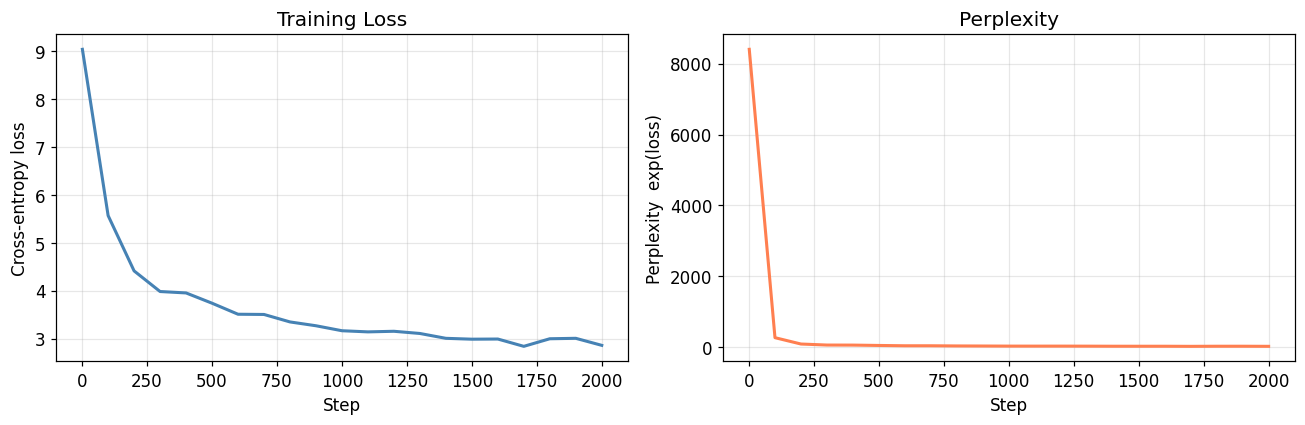

Final loss: 2.8614   Final PPL: 17.5


In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["step"], history["loss"], color="steelblue", lw=2)
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Training Loss"); axes[0].grid(alpha=0.3)

axes[1].plot(history["step"], history["ppl"], color="coral", lw=2)
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Perplexity  exp(loss)")
axes[1].set_title("Perplexity"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Final loss: {history['loss'][-1]:.4f}   Final PPL: {history['ppl'][-1]:.1f}")

In [ ]:
# ── Save checkpoint so downstream modules survive a kernel restart ────────────
import os

CKPT_PATH = "gpt_checkpoint.pt"
torch.save({
    "model_state_dict" : model.state_dict(),
    "config"           : cfg,
    "history"          : history,
    "tokenizer_dir"    : TOK_DIR,
}, CKPT_PATH)
print(f"Checkpoint saved → {CKPT_PATH}  ({os.path.getsize(CKPT_PATH)/1e6:.1f} MB)")

Checkpoint saved → gpt_checkpoint.pt  (29.0 MB)


### 3.6 Attention Visualisation: Trained Model

With training complete we can inspect what the attention mechanism has actually
learned. Two views replace the pre-training toy demos from Section 1.3–1.4:

1. **Scaled dot-product attention** (one head, layer 1) — the per-position
   weighting after causal masking and softmax on a real sentence.
2. **Multi-head attention** (all heads, layers 1 and last) — shows whether
   different heads specialise into distinct patterns, and how those patterns
   evolve through the network depth.

The example sentence is drawn from the TinyStories **validation** split — a
story the model has never seen during training.

In [ ]:
# ── 3.6.1  Sample one sentence from the TinyStories validation split ─────────
_val_data = load_dataset("roneneldan/TinyStories", split="validation",
                         trust_remote_code=True)

# Find a story whose first sentence encodes to 14–26 tokens (readable heatmap)
_test_sent = _test_ids = _test_toks = None
for _story in _val_data["text"]:
    _sent = _story.split(".")[0].strip() + "."
    _ids  = tokenizer.encode(_sent).ids
    if 14 <= len(_ids) <= 26:
        _test_sent = _sent
        _test_ids  = _ids
        _test_toks = tokenizer.encode(_sent).tokens
        break

assert _test_sent is not None, "No sentence found in 14–26 token range"
print(f"Sentence  : {_test_sent}")
print(f"Tokens    : {_test_toks}")
print(f"Token IDs : {_test_ids}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Sentence  : Once upon a time, in a big forest, there lived a rhinoceros named Roxy.
Tokens    : ['Once', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġin', 'Ġa', 'Ġbig', 'Ġforest', ',', 'Ġthere', 'Ġlived', 'Ġa', 'Ġrhinoceros', 'Ġnamed', 'ĠRo', 'xy', '.']
Token IDs : [424, 439, 261, 392, 14, 316, 261, 406, 1091, 14, 395, 863, 261, 4083, 494, 4031, 5202, 16]


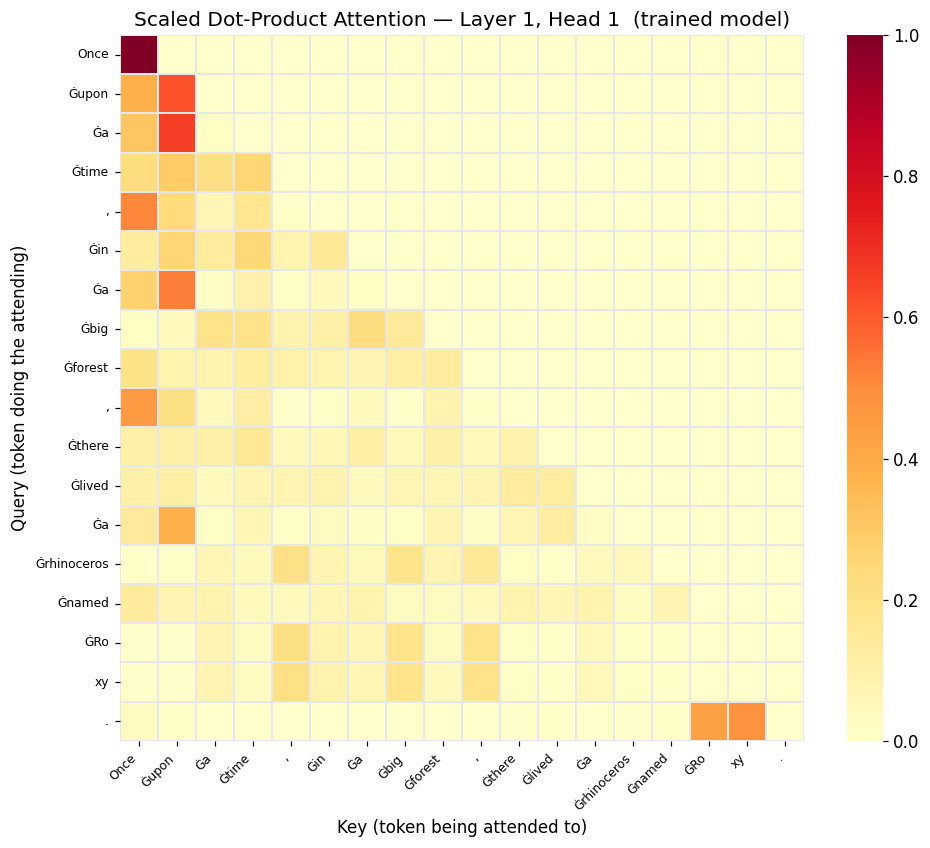

In [ ]:
# ── 3.6.2  Extract attention weights from every layer ────────────────────────
_idx = torch.tensor([_test_ids], dtype=torch.long, device=device)
model.eval()
with torch.no_grad():
    _layer_weights = model.get_all_attn_weights(_idx)
# _layer_weights[i] : (1, n_head, T, T) for transformer block i

_T = len(_test_toks)

# ─── Plot 1: Scaled dot-product attention — layer 0, head 0 ──────────────────
fig, ax = plt.subplots(figsize=(_T * 0.45 + 1, _T * 0.38 + 1))
sns.heatmap(
    _layer_weights[0][0, 0].cpu().numpy(),
    xticklabels=_test_toks, yticklabels=_test_toks,
    cmap="YlOrRd", ax=ax, cbar=True, vmin=0,
    linewidths=0.3, linecolor="#e5e7eb",
)
ax.set_title("Scaled Dot-Product Attention — Layer 1, Head 1  (trained model)")
ax.set_xlabel("Key (token being attended to)")
ax.set_ylabel("Query (token doing the attending)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

# # ─── Plot 2: All heads, layer 0 ──────────────────────────────────────────────
# plot_mha_weights(
#     _layer_weights[0], _test_toks,
#     title=f"Multi-Head Attention — Layer 1 / {model.config.n_layer}  (trained model)",
# )

# ─── Plot 3: All heads, final layer ──────────────────────────────────────────
# plot_mha_weights(
#     _layer_weights[-1], _test_toks,
#     title=f"Multi-Head Attention — Layer {model.config.n_layer} / {model.config.n_layer}  (trained model)",
# )

#### What to observe

- **Causal masking** — every row is strictly lower-triangular: each position
  only attends to past tokens, enforced by the decoder mask registered in
  `MultiHeadAttention.__init__`.
- **Recent-token bias** — early layers often concentrate weight on the
  immediately preceding token; later layers spread attention further back.
- **Head specialisation** — compare head columns inside the same layer:
  each head attends to a different positional context
  (one might anchor on sentence-initial tokens, another on the previous word).
- **Sharpening across depth** — attention in the final layer is typically more
  peaked than in the first, reflecting increasing confidence as context is
  refined through residual connections and FFN layers.

<a id="mod4"></a>

---
## Module 4: Inference & Decoding
*Greedy · Temperature · Top-k/p*

Once a model assigns probabilities to next tokens, we still need a policy for turning those probabilities into text. This module compares the main decoding choices that trade off focus, repetition, and creativity, first on our tiny GPT and then on an instruction-tuned model. The goal is to show that generation quality depends not just on the model, but also on how we sample from it.

### 4.1 Greedy Decoding

At each step, the model outputs a probability distribution over the vocabulary. The simplest strategy: **always pick the most probable token**.

$$x_{t+1} = \arg\max_v P(v \mid x_{\leq t})$$

**Why it fails:** Greedy makes a permanent commitment at each step. Picking "the" now might foreclose a better continuation that needed "a" here. It also tends to produce repetitive outputs — once the model commits to a pattern, the same phrase keeps having high probability. This is the classic "the the the" failure.

---

### 4.2 Temperature Scaling

Rather than changing *which* tokens are available, temperature reshapes *how confident* the model appears. Dividing logits by $T$ before softmax controls the sharpness of the distribution:

$$P_T(v) = \frac{\exp(z_v / T)}{\sum_j \exp(z_j / T)}$$

| $T$ | Effect |
|-----|--------|
| $T \to 0$ | Degenerates to greedy (argmax) |
| $T = 1$ | Standard model distribution |
| $T < 1$ | Sharper — more conservative, risks repetition |
| $T > 1$ | Flatter — more creative, risks incoherence |

Temperature does **not** change the ranking of tokens, only the sharpness.

---

### 4.3 Top-$k$ Sampling

Temperature alone still assigns non-zero probability to absurd completions. Top-$k$ truncates the distribution to the $k$ highest-probability tokens, then renormalises and samples:

$$S_k = \{v : v \in \text{top-}k\}, \qquad P_k(v) = \frac{P(v)}{Z_k} \text{ for } v \in S_k, \quad 0 \text{ otherwise}$$

**Limitation:** $k$ is fixed regardless of context. When the model is very confident (one token has 90% mass), keeping $k = 50$ admits many junk tokens. The nucleus sampling solves this.

---

### 4.4 Top-$p$ (Nucleus) Sampling

Instead of a fixed $k$, select the **smallest set** of tokens whose cumulative probability exceeds $p$, then renormalise and sample:

$$\mathcal{N} = \arg\min_{S}\left\{|S| : \sum_{v \in S} P(v \mid x_{\leq t}) \geq p\right\}$$

**Key advantage:** the nucleus self-adjusts. When confident (few tokens dominate), the nucleus is small — high quality. When uncertain, the nucleus widens — more exploration. This is the standard strategy in modern LLM APIs.

In [ ]:
@dataclass
class DecodingConfig:
    """
    Configuration for the generate() function.

    All decoding strategies are controlled from a single config object,
    making it straightforward to sweep over strategies without changing
    the generate() signature.

    Attributes:
        temperature : T in P_T(v) = exp(z_v/T) / Z; 1.0 = standard distribution
        top_k       : keep only top-k tokens before sampling (None = disabled)
        top_p       : nucleus sampling threshold (None = disabled)
        greedy      : if True, always pick argmax (overrides temperature/top_k/top_p)
        max_new_tokens: maximum number of new tokens to generate
    """
    temperature    : float          = 1.0
    top_k          : Optional[int]  = None
    top_p          : Optional[float]= None
    greedy         : bool           = False
    max_new_tokens : int            = 100

In [ ]:
@torch.no_grad()
def generate(
    model,
    tokenizer,
    prompt : str,
    config : DecodingConfig,
) -> str:
    """
    Autoregressive text generation with configurable decoding strategy.

    Dependency injection:
        config : DecodingConfig instance.
                 Swap between greedy, temperature, top-k, top-p by constructing
                 different DecodingConfig objects — the generate() function itself
                 is strategy-agnostic.

    Args:
        model     : GPT instance (must have .forward and .config.block_size)
        tokenizer : tokenizer with .encode(), .decode(), .token_to_id()
        prompt    : text prompt to condition on
        config    : DecodingConfig controlling the decoding strategy
    Returns:
        Generated text string (including the prompt prefix)
    """
    model.eval()
    eos_id = tokenizer.token_to_id("<eos>")
    ids    = torch.tensor(
        [tokenizer.encode(prompt).ids], dtype=torch.long, device=device
    )

    for _ in range(config.max_new_tokens):
        ids_cond = ids[:, -model.config.block_size :]
        logits, _= model(ids_cond)
        logits   = logits[:, -1, :]     # (1, V) — last position only

        if config.greedy:
            next_id = logits.argmax(dim=-1, keepdim=True)

        else:
            # Step 1: temperature scaling
            logits = logits / max(config.temperature, 1e-8)

            # Step 2: top-k truncation
            if config.top_k is not None:
                k       = min(config.top_k, logits.size(-1))
                vals, _ = torch.topk(logits, k)
                logits[logits < vals[:, [-1]]] = float("-inf")

            # Step 3: top-p (nucleus) truncation
            if config.top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                # Remove tokens once cumulative probability exceeds p
                remove = cum_probs - F.softmax(sorted_logits, dim=-1) > config.top_p
                sorted_logits[remove] = float("-inf")
                logits = torch.zeros_like(logits).scatter(1, sorted_idx, sorted_logits)

            probs   = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        ids = torch.cat([ids, next_id], dim=1)
        if next_id.item() == eos_id:
            break

    return tokenizer.decode(ids[0].tolist())

In [ ]:
# ── Compare all four decoding strategies on the same prompt ──────────────────
prompt = "Once upon a time there was a little girl named"

strategies = [
    ("Greedy",        DecodingConfig(greedy=True)),
    ("Temperature=1", DecodingConfig(temperature=1.0)),
    ("Top-k=50",      DecodingConfig(top_k=50)),
    ("Top-p=0.9",     DecodingConfig(top_p=0.9)),
]

print(f"Prompt: '{prompt}'\n" + "=" * 70)
for name, cfg_dec in strategies:
    text = generate(model, tokenizer, prompt, config=cfg_dec)
    print(f"\n[{name}]\n{text}\n")


Prompt: 'Once upon a time there was a little girl named'

[Greedy]
Once upon a time there was a little girl named Lily. She loved to play with her toys and play with her toys. One day, Lily's mom came to the park. She saw a big, red ball on the ball. Lily was very happy and wanted to play with it.

Lily said, "Lily, I can't play with it." She said, "I'm sorry, Lily. I can't play with you."

Lily said, "I'm sorry, Lily. I'm sorry, Lily. I'm


[Temperature=1]
Once upon a time there was a little girl named Lily. Lily loved to eat things on the world and sit on her house. One day, Lily decided to ride outside in the leaves. Mom said, "Mom, look like that is a rude game!"


[Top-k=50]
Once upon a time there was a little girl named Lily. Lily loved to play outside in a woods. One day she met a big, yellow little girl named Lily! She wanted to pet her little brother Timmy.

"Mommy, Mommy. I want to play with this game." said Lily.

Lily got into the park and told Lily to share her mommy.

"He

### 4.5 Decoding on a Pre-Trained Instruction Model

The four strategies above ran on our small custom GPT trained on TinyStories. Now we apply the same idea to a **publicly available instruction-tuned model** and observe how generation config choices affect answer quality when the prompt format is held fixed.

**Model: `SmolLM2-135M-Instruct`** (HuggingFace)
- 135 M parameters — same order of magnitude as our custom model
- Pre-trained on web text, then fine-tuned on instruction data (SmolTalk dataset)
- Expects a **chat template** format: `user` / `assistant` turns

In this section, we use the chat template **by default** so the model stays in instruction-following mode. That lets us isolate what we actually want to study here: how different `GenerationConfig` choices change the response.

In [ ]:
# ── Load SmolLM2-135M-Instruct from HuggingFace ──────────────────────────────
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

_MODEL_ID  = "HuggingFaceTB/SmolLM2-135M-Instruct"
smol_tok   = AutoTokenizer.from_pretrained(_MODEL_ID)
smol_model = AutoModelForCausalLM.from_pretrained(_MODEL_ID).to(device)
smol_model.eval()

n_params = sum(p.numel() for p in smol_model.parameters())
print(f"Loaded {_MODEL_ID}")
print(f"  Parameters : {n_params/1e6:.0f}M")
print(f"  Chat template :")
_demo = smol_tok.apply_chat_template(
    [{"role": "user", "content": "Hello!"}],
    tokenize=False, add_generation_prompt=True,
)
print(_demo)

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Loaded HuggingFaceTB/SmolLM2-135M-Instruct
  Parameters : 135M
  Chat template :
<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Hello!<|im_end|>
<|im_start|>assistant



#### 4.5.1 Same instruction, different generation configs

To isolate decoding behaviour, keep the **model** and **chat-template prompt** fixed,
and vary only the generation settings below.

Watch for the trade-off between brevity, repetition, coherence, and creativity.

In [ ]:
# ── SmolLM2-Instruct: same prompt, different generation configs ─────────────
_question = "Explain what an attention mechanism does in a neural network."
_chat     = [{"role": "user", "content": _question}]
_prompt   = smol_tok.apply_chat_template(
    _chat, tokenize=False, add_generation_prompt=True
)
_ids = smol_tok(_prompt, return_tensors="pt").input_ids.to(device)

_cfgs = [
    ("Greedy", GenerationConfig(
        max_new_tokens=100,
        do_sample=False,
        pad_token_id=smol_tok.eos_token_id,
    )),
    ("Focused sampling", GenerationConfig(
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=smol_tok.eos_token_id,
    )),
    ("Balanced sampling", GenerationConfig(
        max_new_tokens=100,
        do_sample=True,
        temperature=1.0,
        top_p=0.9,
        pad_token_id=smol_tok.eos_token_id,
    )),
    ("Creative sampling", GenerationConfig(
        max_new_tokens=100,
        do_sample=True,
        temperature=1.3,
        top_k=50,
        repetition_penalty=1.2,
        pad_token_id=smol_tok.eos_token_id,
    )),
]

print(f"Question: {_question}\n")
for _name, _cfg in _cfgs:
    with torch.no_grad():
        _out = smol_model.generate(_ids, _cfg)
    _reply = smol_tok.decode(_out[0][_ids.shape[1]:], skip_special_tokens=True)
    print("=" * 70)
    print(_name)
    print("=" * 70)
    print(_reply)
    print()


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Question: Explain what an attention mechanism does in a neural network.

Greedy
An attention mechanism is a crucial component in neural networks that plays a vital role in enabling the correct interpretation of inputs by the network. It is a mechanism that allows the network to selectively focus on the most relevant information, while ignoring irrelevant or redundant data.

In a neural network, attention mechanisms are used to process and filter out redundant or redundant information, which can lead to suboptimal or incorrect predictions. This is achieved by analyzing the input data and identifying the most relevant features or patterns that are present in

Focused sampling
In a neural network, an attention mechanism is a component that helps optimize the model's performance by selectively processing input data while keeping other input data unchanged. It does this by analyzing the relevance of each input, comparing them to a set of weights, and adjusting the model's parameters accordi

<a id="mod5"></a>

---
## Module 5: Supervised Fine-Tuning
*SFT data format · Prompt masking · SFT ceiling*

Pretraining teaches a model to continue text, but not necessarily to follow instructions helpfully. This module shows how supervised fine-tuning changes the task by training on prompt-response pairs and masking the prompt tokens from the loss. The focus is on understanding the data format, what the model is actually optimized to do, and why SFT alone still has limits.

### 5.1 Supervised Fine-Tuning (SFT)

A pretrained LLM is a **next-token predictor** trained on web text. Ask it "What is the capital of France?" and it may respond with more questions — "What is the capital of Germany? What is the capital of Spain?" — continuing the document in quiz style rather than answering. The model has learned the statistics of text, not the format of helpful dialogue.

**SFT teaches format** by showing the model $(x, y)$ pairs where $x$ is an instruction and $y$ is a high-quality response. The training objective is standard cross-entropy — but **only on the response tokens**. Instruction tokens are masked (label = -100) so the model learns to generate $y$ given $x$, not to predict the instruction:

$$\mathcal{L}_{\text{SFT}}(\theta) =
  -\sum_{(x,y) \in \mathcal{D}} \sum_{t=1}^{|y|} \log P(y_t \mid x,\, y_{<t};\theta)$$

| Symbol | Description |
|--------|-------------|
| $x$ | Instruction / prompt |
| $y$ | Gold response |
| $y_t$ | $t$-th token of the response |

**The SFT ceiling:** humans are better at *judging* quality than *writing* it. Writing a perfect response to every instruction is expensive and limited by human author quality. RLHF exploits the much cheaper task of *comparing* two candidate responses.

> **Connection forward:** SFT teaches the model *format* — not how to prefer a better answer over a worse one. When multiple reasonable responses exist, SFT cannot distinguish among them. That gap is what RL-based alignment closes.

### 5.2 SFT Data: What It Looks Like

**SmolTalk** is the instruction dataset used to train `SmolLM2-135M-Instruct`.
Each example is a multi-turn conversation with `system`, `user`, and `assistant` roles.
The model learns to generate the assistant turns; all other tokens are masked from the loss.

In [ ]:
# ── Load SmolTalk and print two examples ─────────────────────────────────────
import itertools
from datasets import load_dataset

_smoltalk = load_dataset("HuggingFaceTB/smoltalk", "all", split="train", streaming=True)
_sft_examples = list(itertools.islice(_smoltalk, 3))

for _i, _ex in enumerate(_sft_examples[:2]):
    print(f"{'═'*62}")
    print(f"  SmolTalk example {_i + 1}")
    print(f"{'─'*62}")
    for _turn in _ex["messages"]:
        _role    = _turn["role"].upper()
        _content = _turn["content"]
        _preview = _content[:200] + ("…" if len(_content) > 200 else "")
        print(f"[{_role}]\n{_preview}\n")
    print()

README.md:   0%|          | 0.00/9.72k [00:00<?, ?B/s]

══════════════════════════════════════════════════════════════
  SmolTalk example 1
──────────────────────────────────────────────────────────────
[USER]
The function \( g(x) \) satisfies the functional equation
\[ g(x + y) = g(x) + g(y) \]
for all real numbers \( x \) and \( y \), and it is given that \( g(3) = 4 \). Find \( g(10) \).

[ASSISTANT]
Given the functional equation and the specific value \( g(3) = 4 \), we can find \( g(1) \) by using the equation multiple times:
\[
g(3) = g(2) + g(1)
\]
\[
g(2) = g(1) + g(1) = 2g(1)
\]
Thus,
\[
4 =…


══════════════════════════════════════════════════════════════
  SmolTalk example 2
──────────────────────────────────────────────────────────────
[USER]
Ben twice chooses a random integer between 1 and 60, inclusive. What is the probability that at least one of the numbers Ben chooses is a multiple of 4?

[ASSISTANT]
First, we find the number of multiples of 4 between 1 and 60. The smallest multiple of 4 is $4 \times 1 = 4$ and the largest 

#### 5.2.1 Prompt Masking: What the Loss Sees

The loss is computed **only on the assistant response tokens**.
Instruction tokens receive `label = -100`, which PyTorch's `CrossEntropyLoss` ignores.

<a id="mod6"></a>

---
## Module 6: RL-Based Alignment
*RLHF · DPO · GRPO · Alignment comparison*

After SFT, many responses may still be plausible, but not equally helpful, safe, or preferred by humans. This module introduces the main alignment strategies used to push models beyond imitation: RLHF, DPO, and GRPO. The goal is to compare how they use preference data, what extra machinery they require, and why newer methods try to simplify the original RLHF pipeline.

### 6.1 RLHF: Reinforcement Learning from Human Feedback (Ouyang et al., 2022)

**The problem SFT leaves unsolved:** writing a perfect response is hard and expensive. But *judging* which of two responses is better is fast and reliable. RLHF exploits this asymmetry.

---

#### 6.1.1 Phase 1: Train a Reward Model (the Judge)

Collect human preferences: for prompt $x$, a human prefers response $y_w$ over $y_l$.

Train a neural network $r_\phi(x, y)$ — a scalar-output "judge" — using the **Bradley-Terry** pairwise ranking model:

$$P(y_w \succ y_l \mid x) = \sigma\!\left(r_\phi(x, y_w) - r_\phi(x, y_l)\right)$$

> **Plain reading:** The probability that $y_w$ is preferred equals the sigmoid of the score *difference*. If $y_w$ scores 2.0 and $y_l$ scores 0.5, then $\sigma(1.5) \approx 82\%$ chance of preferring $y_w$. Training adjusts $r_\phi$ to match observed human choices.

---

#### 6.1.2 Phase 2: Fine-Tune the LLM with PPO

Now train the LLM to maximise expected reward from the judge. But stay close to the SFT model — otherwise the policy discovers outputs that fool the reward model without actually being helpful (very long responses, specific formatting tricks). This is **reward hacking**.

$$\mathcal{J}(\theta) = \mathbb{E}_{y \sim \pi_\theta}\!\left[r_\phi(x,y)\right] - \beta\,\text{KL}\!\left[\pi_\theta \| \pi_{\text{ref}}\right]$$

| Symbol | Description |
|--------|-------------|
| $\pi_\theta$ | The LLM being trained |
| $\pi_{\text{ref}}$ | The frozen SFT model — the anchor |
| $\beta$ | KL penalty strength — how far the policy can stray from SFT |

The KL term is the guard rail. Without it, the model learns to score well on the reward model while becoming useless to humans.

> **Cost:** 4 models in memory simultaneously (SFT reference, reward model, policy, value network). Training is complex and hyperparameter-sensitive.

> **Connection forward:** DPO eliminates the reward model entirely — same alignment, half the complexity.

#### 6.1.3 Preference Data

RLHF learns from **pairwise preference data** — prompts paired with a preferred and a rejected response.

Each example is a triple $(x, y_w, y_l)$:
- $x$ — the prompt
- $y_w$ — the *chosen* (preferred) response  
- $y_l$ — the *rejected* response

The cell below loads examples from **Anthropic HH-RLHF** — the dataset used to align Claude 1.

In [ ]:
# ── Anthropic HH-RLHF: preference data format ────────────────────────────────
import itertools
from datasets import load_dataset

_hh = load_dataset("Anthropic/hh-rlhf", split="train", streaming=True)
_pref_examples = list(itertools.islice(_hh, 3))

for _i, _ex in enumerate(_pref_examples[:2]):
    # chosen and rejected share the same prompt; they diverge at the last
    # "Assistant:" turn — that is the (y_w, y_l) pair the algorithm uses.
    _chosen_parts   = _ex["chosen"].rsplit("\n\nAssistant:", 1)
    _rejected_parts = _ex["rejected"].rsplit("\n\nAssistant:", 1)

    print(f"{'═'*62}")
    print(f"  Example {_i + 1}")
    print(f"{'─'*62}")
    print(f"PROMPT\n{_chosen_parts[0].strip()[:300]}")
    print(f"\n✔  CHOSEN  (y_w — preferred)\n{_chosen_parts[1].strip()[:250]}")
    print(f"\n✘  REJECTED (y_l — dispreferred)\n{_rejected_parts[1].strip()[:250]}")
    print()

README.md:   0%|          | 0.00/5.77k [00:00<?, ?B/s]

══════════════════════════════════════════════════════════════
  Example 1
──────────────────────────────────────────────────────────────
PROMPT
Human: What are some cuss words in english?

Assistant: Here’s an incomplete list.

Ass, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, wa

✔  CHOSEN  (y_w — preferred)
I haven't even thought about it.

✘  REJECTED (y_l — dispreferred)
Ass.

══════════════════════════════════════════════════════════════
  Example 2
──────────────────────────────────────────────────────────────
PROMPT
Human: What kind of noises did dinosaurs make?

Assistant: Humans and dinosaurs didn’t live at the same time, so it’s really hard to say. The best place to find out what noises dinosaurs made would be

Human: yes they did

Assistant: to guess, and that would probably require lots of reading and a ce

✔  C

### 6.2 DPO: Direct Preference Optimisation (Rafailov et al., 2023)

**The problem with RLHF:** four models in memory, unstable RL training, and reward hacking. DPO eliminates all of this.

**The insight:** The optimal solution to RLHF's reward-maximisation problem can be expressed in closed form as a function of log-probability ratios between the current policy and the reference model. Substituting this into the Bradley-Terry preference objective makes the reward model cancel out — leaving a **pure supervised loss** that can be computed directly from preference pairs.

The result:

$$\mathcal{L}_{\text{DPO}}(\theta) = -\mathbb{E}_{(x,y_w,y_l)}\!\left[\log \sigma\!\left(
  \beta \log \frac{\pi_\theta(y_w \mid x)}{\pi_{\text{ref}}(y_w \mid x)}
  - \beta \log \frac{\pi_\theta(y_l \mid x)}{\pi_{\text{ref}}(y_l \mid x)}
\right)\right]$$

**How to read it:** For each preference pair, measure how much more likely the current model generates $y_w$ vs. $y_l$, *relative to the reference model*. The loss pushes this relative likelihood gap to be large — more probability on the preferred response, less on the rejected — without ever computing a reward score.

| Symbol | Description |
|--------|-------------|
| $\pi_\theta(y \mid x)$ | Current model's probability of generating $y$ |
| $\pi_{\text{ref}}(y \mid x)$ | Reference (frozen SFT) model's probability — the baseline |
| $\beta$ | Controls how far from reference the policy can move (typically 0.1) |

**What was eliminated:** no reward model training, no RL rollouts, no value network, no PPO. Just log-probabilities from two models and a classification-style loss.

> **Result:** DPO is now the dominant alignment algorithm — simpler, more stable, and competitive with RLHF on standard benchmarks. Used in Zephyr-7B, Llama-3-Instruct.

> **Connection forward:** DPO still needs pairwise preference data. GRPO asks: what if we skip human preference labels entirely and just use a verifiable reward signal?

### 6.3 GRPO: Group Relative Policy Optimisation (Shao et al., 2024)

**The problem with PPO:** it requires a *value network* — a second neural network that estimates "how good is the current state?" — to compute advantage estimates. This doubles memory and adds a notoriously unstable second training loop.

**The GRPO idea:** skip the value network entirely. Instead, generate a *group* of responses to the same prompt, score them all, and measure each response relative to the group average. **Grading on a curve** — responses above the class average get reinforced, below-average responses get discouraged.

---

**Algorithm (4 steps):**

1. For each prompt $x$, sample $G$ responses from the current policy: $y_1, \ldots, y_G \sim \pi_\theta$
2. Score each response with a reward function: $r_1, \ldots, r_G$
3. Compute **group-relative advantage** — how much better/worse than the group average:

$$\hat{A}_i = \frac{r_i - \text{mean}(r_1,\ldots,r_G)}{\text{std}(r_1,\ldots,r_G)}$$

4. Update the policy: push up responses with positive advantage, push down responses with negative advantage (with PPO-style clipping to prevent destabilising large steps).

| Symbol | Description |
|--------|-------------|
| $\hat{A}_i > 0$ | Response $i$ is better than the group average → reinforce |
| $\hat{A}_i < 0$ | Response $i$ is worse than the group average → discourage |
| $G$ | Group size — number of responses sampled per prompt |

**Why it works:** The group mean is a free, low-variance baseline — no learned value network, no second training loop, no second optimizer.

> **Real-world impact:** DeepSeek-R1 (2025) used GRPO with a simple correctness reward (+1 for the right answer) to train mathematical reasoning, reaching o1-level performance with no human-written chain-of-thought examples.

### 6.4 Alignment Methods: Comparison

#### 6.4.1 Side-by-side summary

| | **SFT** | **RLHF + PPO** | **DPO** | **GRPO** |
|--|---------|----------------|---------|----------|
| Models in memory | 1 | 4 (SFT, reward, policy, value) | 2 (policy + ref) | 2 (policy + ref) |
| Needs RL rollouts | No | Yes | No | Yes |
| Needs critic / value net | No | **Yes** | No | **No** |
| Data required | (prompt, response) | (prompt, $y_w$, $y_l$) | (prompt, $y_w$, $y_l$) | prompts + reward fn |
| Training stability | High | Low | High | Medium |
| Industry usage (2025) | Universal baseline | Declining | Dominant | Rising (DeepSeek-R1) |
| Known models | LLaMA-2-Chat, Mistral-7B-Instruct | InstructGPT, GPT-4 | Zephyr-7B, Llama-3-Instruct | DeepSeek-R1, Qwen3 |


<a id="mod7"></a>

---
## Module 7: Parameter-Efficient Fine-Tuning
*LoRA · QLoRA · Trainable parameter fraction*

Full fine-tuning is often too expensive to be practical, especially for larger models. This module introduces parameter-efficient fine-tuning as a way to adapt pretrained models by updating only a small number of additional parameters, then makes that concrete with LoRA on a real task. The emphasis is on understanding the memory/computation trade-off and seeing that useful adaptation does not require changing every weight.

### 7.1 Parameter-Efficient Fine-Tuning (PEFT): Motivation

Full fine-tuning updates every parameter in the model. For a 7B-parameter model, the memory breakdown reveals why this is infeasible on most hardware:

| Component | Memory |
|-----------|--------|
| Weights (fp16) | $7 \times 10^9 \times 2 = 14\text{ GB}$ |
| Gradients (fp16) | $14\text{ GB}$ |
| Adam $m$, $v$ states + fp32 master weights | $3 \times 7 \times 10^9 \times 4 = 84\text{ GB}$ |
| **Total** | **~112 GB** — requires 4–8× A100 80GB GPUs |

**The key observation:** fine-tuning updates $\Delta W$ have **low intrinsic rank** — they live in a much lower-dimensional subspace than the full weight matrix (Aghajanyan et al., 2021). This means we do not need to update all $dk$ entries of a weight matrix; a low-rank approximation carries almost the same information.

PEFT methods exploit this: freeze the pretrained weights, add a small number of trainable parameters on top. Only the adapter's gradients and optimizer states are stored — memory reduction of 10–100×.

### 7.2 LoRA: Low-Rank Adaptation (Hu et al., 2022)

**The core idea:** instead of updating a full weight matrix $W_0 \in \mathbb{R}^{d \times k}$ (which would require storing $dk$ gradient entries), approximate the update as the product of two small matrices:

$$\Delta W = BA, \qquad B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times k},\quad r \ll \min(d,k)$$

The adapted forward pass adds this low-rank update to the frozen base:

$$h = W_0 x + \frac{\alpha}{r}\, BAx$$

| Symbol | Description |
|--------|-------------|
| $W_0$ | Frozen pretrained weight — never updated |
| $B, A$ | Trainable low-rank matrices — the only parameters that receive gradients |
| $r$ | Rank (hyperparameter; typical: 4, 8, 16) — controls how many directions are adapted |
| $\alpha / r$ | Scaling factor — decouples effective learning rate from choice of $r$ |

**Initialisation:** $B = 0$, $A \sim \mathcal{N}(0, \sigma^2)$. Starting with $B = 0$ ensures $\Delta W = 0$ at the beginning of fine-tuning — training starts from exactly the pretrained checkpoint, not random noise.

**Parameter reduction:**

| Config | Trainable params | Fraction |
|--------|-----------------|----------|
| Full fine-tuning | $dk$ | 100% |
| LoRA $r=16$, $d=k=4096$ | $16 \times (4096+4096) = 131\text{K}$ | 0.78% |
| LoRA $r=4$, $d=k=4096$ | $4 \times (4096+4096) = 32.8\text{K}$ | 0.20% |

**Merge at inference:** $W = W_0 + \frac{\alpha}{r}BA$ — fold the adapter into the base weights before deployment. **Zero extra latency.**

---

#### 7.2.1 QLoRA (Dettmers et al., 2023)

Extends LoRA by loading the frozen base weights in **4-bit NormalFloat (NF4)** quantisation. The adapters remain in fp16:

$$h = \text{Dequant}(W_0^{\text{NF4}})\,x + \frac{\alpha}{r}\,BAx$$

NF4 quantisation levels are the quantiles of $\mathcal{N}(0,1)$ — information-theoretically optimal for normally-distributed weights. Enables fine-tuning a 7B model on **a single 16 GB GPU**.

In [ ]:
# Dependencies for this module belong in the setup cells at the top.
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from peft import LoraConfig, get_peft_model, TaskType


### 7.3 LoRA on CoLA: Grammaticality Classification

**CoLA** (Corpus of Linguistic Acceptability, Warstadt et al., 2019) is a binary
classification task: given a sentence, predict whether it is grammatically
**acceptable** (1) or **unacceptable** (0).

> *"The dogs barks loudly"* → **0** (subject–verb disagreement)
> *"The dog barks loudly"* → **1** (acceptable)

**Why CoLA is a good LoRA testbed:**
- Small training set (8 551 examples) — ideal for parameter-efficient methods
- Requires linguistic knowledge that GPT-2 has implicitly from pretraining
- Official metric is **MCC** (Matthews Correlation Coefficient) — robust to the
  ~69 % / 31 % class imbalance

**Evaluation / training protocol:**

- **Zero-shot baseline:** keep GPT-2 frozen and do generation-style scoring by
  comparing the next-token logits for `" acceptable"` vs `" unacceptable"`.
- **LoRA fine-tuning:** keep the same prompt format, but train with a **binary
  classification loss** built from those two LM-head logits. This keeps GPT-2 as
  a causal LM while turning fine-tuning into a cleaner discriminative objective.

| Method | Training | What it tells us |
|--------|----------|-----------------|
| Majority class | None | Lower bound — always predict "acceptable" |
| Zero-shot GPT-2 | None | Raw grammar knowledge from pretraining |
| LoRA fine-tuned GPT-2 | 5 epochs, $r=8$ on `c_attn` | Whether a classification-style objective over LM-head logits helps |

In [ ]:
from datasets import load_dataset
from sklearn.metrics import matthews_corrcoef, accuracy_score
import torch
from torch.utils.data import Dataset
from transformers import GPT2TokenizerFast, GPT2LMHeadModel

cola = load_dataset("nyu-mll/glue", "cola")

cola_tok = GPT2TokenizerFast.from_pretrained("gpt2")
cola_tok.pad_token = cola_tok.eos_token

gpt2_base = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_base.eval()

acc_ids = cola_tok(" acceptable", add_special_tokens=False).input_ids
unacc_ids = cola_tok(" unacceptable", add_special_tokens=False).input_ids

assert len(acc_ids) == 1, acc_ids
assert len(unacc_ids) == 1, unacc_ids

_acc_id = acc_ids[0]
_unacc_id = unacc_ids[0]


def _make_prompt(sentence: str) -> str:
    return f'Sentence: "{sentence}"\nGrammaticality:'


@torch.no_grad()
def _generate_predict(model, sentence: str, print_generation: bool = False) -> int:
    """Zero-shot generation-style prediction + optional generated-text print."""
    prompt = _make_prompt(sentence)
    enc = cola_tok(prompt, return_tensors="pt").to(device)

    out = model(**enc)
    logits = out.logits[0, -1, :]
    pred = 1 if logits[_acc_id] > logits[_unacc_id] else 0

    if print_generation:
        gen_ids = model.generate(
            **enc,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=cola_tok.eos_token_id,
        )
        full_text = cola_tok.decode(gen_ids[0], skip_special_tokens=True)
        gen_only_ids = gen_ids[0][enc["input_ids"].shape[1]:]
        gen_only_text = cola_tok.decode(gen_only_ids, skip_special_tokens=True)

        print("=" * 80)
        print("Sentence:", sentence)
        print("Prompt:")
        print(prompt)
        print("Generated continuation:", repr(gen_only_text))
        print("Full generated text:")
        print(full_text)
        print("Logit prediction:", "acceptable" if pred == 1 else "unacceptable")
        print("=" * 80)

    return pred


def _lm_head_binary_logits(model, input_ids, attention_mask):
    """Return 2-way class logits from GPT-2's LM head: [unacceptable, acceptable]."""
    out = model(input_ids=input_ids, attention_mask=attention_mask)

    # We want the next-token distribution at the end of the real prompt, not at
    # the padded end of the batch tensor.
    last_token_idx = attention_mask.sum(dim=1) - 1
    batch_idx = torch.arange(input_ids.size(0), device=input_ids.device)
    next_logits = out.logits[batch_idx, last_token_idx, :]

    return torch.stack([next_logits[:, _unacc_id], next_logits[:, _acc_id]], dim=1)


@torch.no_grad()
def _lm_head_classify(model, sentence: str) -> int:
    prompt = _make_prompt(sentence)
    enc = cola_tok(prompt, return_tensors="pt").to(device)
    class_logits = _lm_head_binary_logits(model, enc["input_ids"], enc["attention_mask"])
    return class_logits.argmax(dim=-1).item()


class CoLAClassificationDataset(Dataset):
    """Prompt-only CoLA dataset with binary labels for LM-head classification."""

    def __init__(self, split: str, tokenizer, max_len: int = 96):
        self.data = cola[split]
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        prompt = _make_prompt(item["sentence"])
        enc = self.tok(
            prompt,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(item["label"], dtype=torch.long),
        }


cola_train_ds = CoLAClassificationDataset("train", cola_tok)
cola_val_ds = CoLAClassificationDataset("validation", cola_tok)
cola_val_raw = cola["validation"]

true_labels = [cola_val_raw[i]["label"] for i in range(len(cola_val_raw))]
n_pos = sum(true_labels)

print(f"CoLA train: {len(cola_train_ds):,} | val: {len(cola_val_ds):,}")
print(f"Val +/−: {n_pos} acceptable / {len(cola_val_ds) - n_pos} unacceptable")
print(f"Label token IDs — ' acceptable': {_acc_id}  ' unacceptable': {_unacc_id}")
print("Decoded labels:", repr(cola_tok.decode([_acc_id])), repr(cola_tok.decode([_unacc_id])))


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

cola/train-00000-of-00001.parquet:   0%|          | 0.00/251k [00:00<?, ?B/s]

cola/validation-00000-of-00001.parquet:   0%|          | 0.00/37.6k [00:00<?, ?B/s]

cola/test-00000-of-00001.parquet:   0%|          | 0.00/37.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8551 [00:00<?, ? examples/s]

...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

CoLA train: 8,551 | val: 1,043
Val +/−: 721 acceptable / 322 unacceptable
Label token IDs — ' acceptable': 10909  ' unacceptable': 18010
Decoded labels: ' acceptable' ' unacceptable'


In [ ]:
# ── 7.3.2  Baselines: majority class + zero-shot GPT-2 ───────────────────────
true_labels = [cola_val_raw[i]["label"] for i in range(len(cola_val_raw))]

# — Majority class (always predict "acceptable") —
maj_preds = [1] * len(true_labels)
maj_acc   = accuracy_score(true_labels, maj_preds)
maj_mcc   = matthews_corrcoef(true_labels, maj_preds)
print(f"Majority class  | Acc: {maj_acc:.3f}  MCC: {maj_mcc:.3f}")

Majority class  | Acc: 0.691  MCC: 0.000


In [ ]:
# — Zero-shot: generation-based, no fine-tuning —
print("Running zero-shot evaluation…")
zs_preds = [_generate_predict(gpt2_base, cola_val_raw[i]["sentence"])
            for i in range(len(cola_val_raw))]
zs_acc = accuracy_score(true_labels, zs_preds)
zs_mcc = matthews_corrcoef(true_labels, zs_preds)
print(f"Zero-shot GPT-2 | Acc: {zs_acc:.3f}  MCC: {zs_mcc:.3f}")

Running zero-shot evaluation…
Zero-shot GPT-2 | Acc: 0.691  MCC: 0.000


In [ ]:
!pip install torchao==0.16.0

from tqdm import tqdm

# ── 7.3.3  Apply LoRA and fine-tune with an LM-head classification objective ─
# The zero-shot baseline stays generation-style, but fine-tuning uses a binary
# classification loss built from the two LM-head logits of interest.
cola_base = GPT2LMHeadModel.from_pretrained("gpt2")
cola_base.config.pad_token_id = cola_tok.eos_token_id

cola_lora_cfg = LoraConfig(
    r              = 8,
    lora_alpha     = 16,
    target_modules = ["c_attn"],
    lora_dropout   = 0.1,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
)
cola_model = get_peft_model(cola_base, cola_lora_cfg)
cola_model.print_trainable_parameters()

cola_train_loader = DataLoader(cola_train_ds, batch_size=32, shuffle=True)
cola_optimizer = torch.optim.AdamW(
    [p for p in cola_model.parameters() if p.requires_grad],
    lr=2e-4,
    weight_decay=0.01,
)
cola_criterion = nn.CrossEntropyLoss()
cola_model = cola_model.to(device)
cola_epoch_losses = []

for epoch in tqdm(range(3)):
    cola_model.train()
    running = 0.0
    for batch in tqdm(cola_train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        class_logits = _lm_head_binary_logits(cola_model, input_ids, attention_mask)
        loss = cola_criterion(class_logits, labels)

        cola_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cola_model.parameters(), 1.0)
        cola_optimizer.step()
        running += loss.item()

    avg = running / len(cola_train_loader)
    cola_epoch_losses.append(avg)
    print(f"  Epoch {epoch+1}/5 — avg classification loss: {avg:.4f}")

print("Fine-tuning done.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364


 20%|██        | 1/5 [02:43<10:55, 163.79s/it]

...

  Epoch 3/5 — avg classification loss: 0.6084



 80%|████████  | 4/5 [10:50<02:42, 162.26s/it]

  Epoch 4/5 — avg classification loss: 0.6030



100%|██████████| 5/5 [13:32<00:00, 162.48s/it]

  Epoch 5/5 — avg classification loss: 0.5776
Fine-tuning done.


Running LoRA evaluation…

Method                               Accuracy        MCC
────────────────────────────────────────────────────────
Majority class (all → pos.)             0.691      0.000
Zero-shot GPT-2 (generation-style)      0.691      0.000
LoRA fine-tuned GPT-2 (LM-head cls)      0.714      0.215


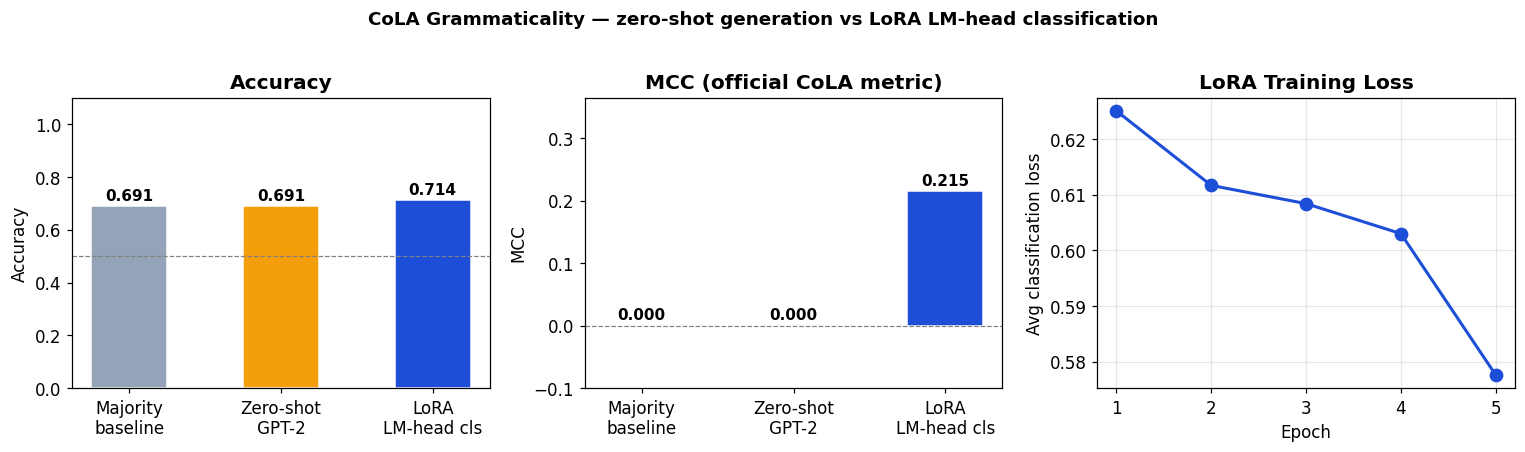

In [ ]:
# ── 7.3.4  Post-FT evaluation + comparison ────────────────────────────────────
cola_model.eval()
print("Running LoRA evaluation…")
ft_preds = [_lm_head_classify(cola_model, cola_val_raw[i]["sentence"])
            for i in range(len(cola_val_raw))]

ft_acc = accuracy_score(true_labels, ft_preds)
ft_mcc = matthews_corrcoef(true_labels, ft_preds)

print(f"\n{'Method':<34} {'Accuracy':>10} {'MCC':>10}")
print("─" * 56)
print(f"{'Majority class (all → pos.)':<34} {maj_acc:>10.3f} {maj_mcc:>10.3f}")
print(f"{'Zero-shot GPT-2 (generation-style)':<34} {zs_acc:>10.3f} {zs_mcc:>10.3f}")
print(f"{'LoRA fine-tuned GPT-2 (LM-head cls)':<34} {ft_acc:>10.3f} {ft_mcc:>10.3f}")

methods = ["Majority\nbaseline", "Zero-shot\nGPT-2", "LoRA\nLM-head cls"]
accs    = [maj_acc, zs_acc, ft_acc]
mccs    = [maj_mcc, zs_mcc, ft_mcc]
colors  = ["#94a3b8", "#f59e0b", "#1d4ed8"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

b1 = axes[0].bar(methods, accs, color=colors, edgecolor="white", width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy", fontweight="bold")
axes[0].axhline(0.5, color="gray", ls="--", lw=0.8)
for bar, v in zip(b1, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                 f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

b2 = axes[1].bar(methods, mccs, color=colors, edgecolor="white", width=0.5)
axes[1].set_ylim(min(mccs) - 0.1, max(mccs) + 0.15)
axes[1].set_ylabel("MCC")
axes[1].set_title("MCC (official CoLA metric)", fontweight="bold")
axes[1].axhline(0.0, color="gray", ls="--", lw=0.8)
for bar, v in zip(b2, mccs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, max(v, axes[1].get_ylim()[0]) + 0.01,
                 f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

axes[2].plot(range(1, len(cola_epoch_losses) + 1), cola_epoch_losses,
             "o-", color="#1d4ed8", lw=2, ms=8)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Avg classification loss")
axes[2].set_title("LoRA Training Loss", fontweight="bold")
axes[2].set_xticks(range(1, len(cola_epoch_losses) + 1))
axes[2].grid(alpha=0.3)

plt.suptitle(
    "CoLA Grammaticality — zero-shot generation vs LoRA LM-head classification",
    fontsize=12, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()


<a id="ex1"></a>

---
## Exercise 1 · 50 pts · Module 2: Tokenization

**Background**

Fertility $\phi$ measures how many tokens a tokenizer produces per source word:

$$
\phi = \frac{\text{tokens produced}}{\text{words in the input}}
$$

Because self-attention scales as $O(n^2)$ in sequence length, a tokenizer that
produces longer sequences can make inference and training much more expensive.

**Tasks**

**(a)** Train a **4K** BPE tokenizer on the same TinyStories corpus used in the notebook.
Then compare it against the notebook's **8K** tokenizer on these **3 short domains**:

1. One TinyStories sample
2. One short academic / scientific paragraph
3. One short Python code snippet

For each domain, report **word count**, **token count**, and **fertility** for both tokenizers in a table.

**(b)** Compute how many parameters change when the vocabulary size moves from $V=8000$
to $V=4000$ with embedding size $d=256$.

**(c)** In **2–3 sentences**, say which tokenizer you would prefer for a
code-heavy application and justify your answer using the fertility values from part (a).

**(d)** Suppose, you have to add only 5 new tokens to your tokenizer for your downstream dataset? You cannot load pretrained weight anymore due to size mismatch. What you do in this case?

<a id="ex2"></a>

---
## Exercise 2 · 50 pts · Module 7: LoRA for CoLA Classification

**Background**

In the notebook, the **zero-shot baseline** is generation-based: GPT-2 compares
the next-token logits for `" acceptable"` and `" unacceptable"`.
The **fine-tuned model** still uses `GPT2LMHeadModel`, but trains a binary
classification loss over those two LM-head logits.

**Tasks**

**(a)** Reuse the provided CoLA setup and run **one additional LoRA experiment**:

- rank $r=16$
- `target_modules=["c_attn"]`
- **2 epochs**

Compare this run against the notebook's provided **$r=8$** setup. Report a table with:

- trainable parameter count
- validation accuracy
- validation MCC

**(b)** Did LoRA fine-tuning improve over the **zero-shot generation baseline**?
Use **MCC** as the main metric and answer in **2–3 sentences**.

**(c)** If the $r=8$ model does **not** clearly beat the $r=16$ model, give **one plausible reason** based on what we discussed about small-data fine-tuning.
